# **IMPORTING REQUIRED LIBRARIES**

In [ ]:
import pandas as pd
import numpy as np
import seaborn as snsb
import matplotlib.pyplot as plt
from google.colab import drive

from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score
from scipy.stats import skew
from sklearn.linear_model import Ridge, Lasso
from xgboost import XGBRegressor

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import GridSearchCV

In [ ]:
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!ls /content/drive/MyDrive

'Colab Notebooks'
 kaggle.json
'SaSS kleptocracy Phase 1 deliverables .gdoc'
'train (1).gsheet'
 train.csv
 train.gsheet
'Untitled spreadsheet (1).gsheet'
'Untitled spreadsheet.gsheet'


In [ ]:
!mkdir -p ~/.kaggle
!cp /content/drive/MyDrive/kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# **DATA EXTRACTION**

In [ ]:
# Download the dataset file to local storage to current directory (from publicly
# shared drive file)
#
#Original source:
!kaggle competitions download -c house-prices-advanced-regression-techniques

  0% 0.00/199k [00:00<?, ?B/s]
100% 199k/199k [00:00<00:00, 548MB/s]


In [ ]:
!unzip house-prices-advanced-regression-techniques.zip -d ./data

Archive:  house-prices-advanced-regression-techniques.zip
  inflating: ./data/data_description.txt  
  inflating: ./data/sample_submission.csv  
  inflating: ./data/test.csv         
  inflating: ./data/train.csv        


# **LOADING THE DATASET FILE INTO MEMORY**

In [ ]:
# pd.set_option('display.max_rows', None)
# pd.set_option('display.max_columns', None)
DATASET_PATH = "./data/train.csv"
df = pd.read_csv(DATASET_PATH)
df.shape

(1460, 81)

In [ ]:
df

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,1456,60,RL,62.0,7917,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,175000
1456,1457,20,RL,85.0,13175,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,2,2010,WD,Normal,210000
1457,1458,70,RL,66.0,9042,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,GdPrv,Shed,2500,5,2010,WD,Normal,266500
1458,1459,20,RL,68.0,9717,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,142125


TIME FRAME

In [ ]:
#df['YearBuilt'].min() #--1872. #Original construction date
#df['YearBuilt'].max() --2010

#df['YearRemodAdd'].min()--1950. # Remodel date
#df['YearRemodAdd'].max() --2010

#df['GarageYrBlt'].min()--1900.0. #Year garage was built
#df['GarageYrBlt'].max()--2010.0

#df['YrSold'].min()--2006. #Year Sold
#df['YrSold'].max()--2010

# **REVIEWING UNIQUE VALUES IN ALL COLUMNS**

In [ ]:
object_column_names = df.select_dtypes(include=['object']).columns
for column_name in object_column_names:
  print(f"Unique values in column '{column_name}':", df[column_name].dropna().unique())

Unique values in column 'MSZoning': ['RL' 'RM' 'C (all)' 'FV' 'RH']
Unique values in column 'Street': ['Pave' 'Grvl']
Unique values in column 'Alley': ['Grvl' 'Pave']
Unique values in column 'LotShape': ['Reg' 'IR1' 'IR2' 'IR3']
Unique values in column 'LandContour': ['Lvl' 'Bnk' 'Low' 'HLS']
Unique values in column 'Utilities': ['AllPub' 'NoSeWa']
Unique values in column 'LotConfig': ['Inside' 'FR2' 'Corner' 'CulDSac' 'FR3']
Unique values in column 'LandSlope': ['Gtl' 'Mod' 'Sev']
Unique values in column 'Neighborhood': ['CollgCr' 'Veenker' 'Crawfor' 'NoRidge' 'Mitchel' 'Somerst' 'NWAmes'
 'OldTown' 'BrkSide' 'Sawyer' 'NridgHt' 'NAmes' 'SawyerW' 'IDOTRR'
 'MeadowV' 'Edwards' 'Timber' 'Gilbert' 'StoneBr' 'ClearCr' 'NPkVill'
 'Blmngtn' 'BrDale' 'SWISU' 'Blueste']
Unique values in column 'Condition1': ['Norm' 'Feedr' 'PosN' 'Artery' 'RRAe' 'RRNn' 'RRAn' 'PosA' 'RRNe']
Unique values in column 'Condition2': ['Norm' 'Artery' 'RRNn' 'Feedr' 'PosN' 'PosA' 'RRAn' 'RRAe']
Unique values in colum

# **FINDING NA/NULL OR MISSING VALUES IN ALLCOLUMNS (BEFORE)**

In [ ]:
# isnull() returns a dataframe of the same shape and labels as the original
# with null values mapped to TRUE and others mapped to FALSE
null_bool_df = df.isnull()

# We wish to know the number of null values in each column, therefore
# we'll aggregate these values with the help of sum functionj
null_value_counts = null_bool_df.sum()

# Instead of manually going through each column, it would be more practical
# to sort the dataframe as per the number of data columns on priority basis
null_value_counts_sorted = null_value_counts.sort_values(ascending=False)
print(null_value_counts_sorted.to_string())

PoolQC           1453
MiscFeature      1406
Alley            1369
Fence            1179
MasVnrType        872
FireplaceQu       690
LotFrontage       259
GarageQual         81
GarageFinish       81
GarageType         81
GarageYrBlt        81
GarageCond         81
BsmtFinType2       38
BsmtExposure       38
BsmtCond           37
BsmtQual           37
BsmtFinType1       37
MasVnrArea          8
Electrical          1
Condition2          0
BldgType            0
Neighborhood        0
LandSlope           0
LotConfig           0
Condition1          0
LandContour         0
LotShape            0
Street              0
LotArea             0
MSSubClass          0
MSZoning            0
Id                  0
Utilities           0
HouseStyle          0
Foundation          0
ExterQual           0
ExterCond           0
BsmtUnfSF           0
TotalBsmtSF         0
Heating             0
BsmtFinSF1          0
Exterior2nd         0
Exterior1st         0
RoofMatl            0
RoofStyle           0
YearRemodA

In [ ]:
df = df.drop(columns=['Id', 'Alley', 'PoolQC', 'Fence', 'MiscFeature'])
df

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,LandSlope,...,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,60,RL,65.0,8450,Pave,Reg,Lvl,AllPub,Inside,Gtl,...,0,0,0,0,0,2,2008,WD,Normal,208500
1,20,RL,80.0,9600,Pave,Reg,Lvl,AllPub,FR2,Gtl,...,0,0,0,0,0,5,2007,WD,Normal,181500
2,60,RL,68.0,11250,Pave,IR1,Lvl,AllPub,Inside,Gtl,...,0,0,0,0,0,9,2008,WD,Normal,223500
3,70,RL,60.0,9550,Pave,IR1,Lvl,AllPub,Corner,Gtl,...,272,0,0,0,0,2,2006,WD,Abnorml,140000
4,60,RL,84.0,14260,Pave,IR1,Lvl,AllPub,FR2,Gtl,...,0,0,0,0,0,12,2008,WD,Normal,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,60,RL,62.0,7917,Pave,Reg,Lvl,AllPub,Inside,Gtl,...,0,0,0,0,0,8,2007,WD,Normal,175000
1456,20,RL,85.0,13175,Pave,Reg,Lvl,AllPub,Inside,Gtl,...,0,0,0,0,0,2,2010,WD,Normal,210000
1457,70,RL,66.0,9042,Pave,Reg,Lvl,AllPub,Inside,Gtl,...,0,0,0,0,2500,5,2010,WD,Normal,266500
1458,20,RL,68.0,9717,Pave,Reg,Lvl,AllPub,Inside,Gtl,...,112,0,0,0,0,4,2010,WD,Normal,142125


# **COLUMN IMPUTATION (NUMERIC COLUMNS)**

In [ ]:
# Impute the missing year with 0, as the corresponding houses have no garage.
df['GarageYrBlt'] = df['GarageYrBlt'].fillna(0)

# Correct LotFrontage: Impute missing values with the median of its specific Neighborhood.
df['LotFrontage'] = df.groupby('Neighborhood')['LotFrontage'].transform(lambda x: x.fillna(x.median()))

df = df.fillna(df.median(numeric_only=True)) #Calculates the median for every column in the DataFrame
                                             #that contains purely numerical data.

# **ADDING NEW COLUMNS (NUMERIC FEATURES)**

In [ ]:
#Total square footage (basement + 1st + 2nd floor)
df['TotalSF'] = df['TotalBsmtSF'] + df['1stFlrSF'] + df['2ndFlrSF']

#Total bathrooms (including basement baths)
df['TotalBath'] = (
    df['FullBath'] +
    0.5 * df['HalfBath'] +
    df['BsmtFullBath'] +
    0.5 * df['BsmtHalfBath']
)

# House age at sale
df['HouseAgeAtSale'] = df['YrSold'] - df['YearBuilt']

# Years since remodel
df['YearsSinceRemodel'] = df['YrSold'] - df['YearRemodAdd']

# Garage age (0 if no garage year)
df['GarageAge'] = df['YrSold'] - df['GarageYrBlt']
df.loc[df['GarageYrBlt'] == 0, 'GarageAge'] = 0  # override nonsense ages

# Total porch area
df['TotalPorchSF'] = (
    df['OpenPorchSF'] +
    df['EnclosedPorch'] +
    df['3SsnPorch'] +
    df['ScreenPorch']
)

# Was the house remodeled? (binary flag)
df['Remodeled'] = (df['YearBuilt'] != df['YearRemodAdd']).astype(int)


In [ ]:
# df.median(numeric_only=True)

# **COLUMN IMPUTATION (CATEGORICAL COLUMN)**

In [ ]:
df['Electrical'] = df['Electrical'].fillna(df['Electrical'].mode()[0])
df = df.fillna("None")  #Replaces any remaining NaN values with the string value "None".
df

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,LandSlope,...,SaleType,SaleCondition,SalePrice,TotalSF,TotalBath,HouseAgeAtSale,YearsSinceRemodel,GarageAge,TotalPorchSF,Remodeled
0,60,RL,65.0,8450,Pave,Reg,Lvl,AllPub,Inside,Gtl,...,WD,Normal,208500,2566,3.5,5,5,5.0,61,0
1,20,RL,80.0,9600,Pave,Reg,Lvl,AllPub,FR2,Gtl,...,WD,Normal,181500,2524,2.5,31,31,31.0,0,0
2,60,RL,68.0,11250,Pave,IR1,Lvl,AllPub,Inside,Gtl,...,WD,Normal,223500,2706,3.5,7,6,7.0,42,1
3,70,RL,60.0,9550,Pave,IR1,Lvl,AllPub,Corner,Gtl,...,WD,Abnorml,140000,2473,2.0,91,36,8.0,307,1
4,60,RL,84.0,14260,Pave,IR1,Lvl,AllPub,FR2,Gtl,...,WD,Normal,250000,3343,3.5,8,8,8.0,84,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,60,RL,62.0,7917,Pave,Reg,Lvl,AllPub,Inside,Gtl,...,WD,Normal,175000,2600,2.5,8,7,8.0,40,1
1456,20,RL,85.0,13175,Pave,Reg,Lvl,AllPub,Inside,Gtl,...,WD,Normal,210000,3615,3.0,32,22,32.0,0,1
1457,70,RL,66.0,9042,Pave,Reg,Lvl,AllPub,Inside,Gtl,...,WD,Normal,266500,3492,2.0,69,4,69.0,60,1
1458,20,RL,68.0,9717,Pave,Reg,Lvl,AllPub,Inside,Gtl,...,WD,Normal,142125,2156,2.0,60,14,60.0,112,1


# **FINDING NA/NULL OR MISSING VALUES IN ALL COLUMNS (AFTER)**


In [ ]:
# isnull() returns a dataframe of the same shape and labels as the original
# with null values mapped to TRUE and others mapped to FALSE
null_bool_df = df.isnull()

# We wish to know the number of null values in each column, therefore
# we'll aggregate these values with the help of sum functionj
null_value_counts = null_bool_df.sum()

# Instead of manually going through each column, it would be more practical
# to sort the dataframe as per the number of data columns on priority basis
null_value_counts_sorted = null_value_counts.sort_values(ascending=False)
print(null_value_counts_sorted.to_string())

MSSubClass           0
MSZoning             0
LotFrontage          0
LotArea              0
Street               0
LotShape             0
LandContour          0
Utilities            0
LotConfig            0
LandSlope            0
Neighborhood         0
Condition1           0
Condition2           0
BldgType             0
HouseStyle           0
OverallQual          0
OverallCond          0
YearBuilt            0
YearRemodAdd         0
RoofStyle            0
RoofMatl             0
Exterior1st          0
Exterior2nd          0
MasVnrType           0
MasVnrArea           0
ExterQual            0
ExterCond            0
Foundation           0
BsmtQual             0
BsmtCond             0
BsmtExposure         0
BsmtFinType1         0
BsmtFinSF1           0
BsmtFinType2         0
BsmtFinSF2           0
BsmtUnfSF            0
TotalBsmtSF          0
Heating              0
HeatingQC            0
CentralAir           0
Electrical           0
1stFlrSF             0
2ndFlrSF             0
LowQualFinS

# **CHECKING FOR DUPLICATE RECORDS**

In [ ]:
duplicate_row_indices = df.duplicated()
duplicate_rows = df[duplicate_row_indices]
duplicate_rows

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,LandSlope,...,SaleType,SaleCondition,SalePrice,TotalSF,TotalBath,HouseAgeAtSale,YearsSinceRemodel,GarageAge,TotalPorchSF,Remodeled


# **DETECTING OUTLIERS IN DATASET USING VISUALIZATIONS**

<Axes: ylabel='SalePrice'>

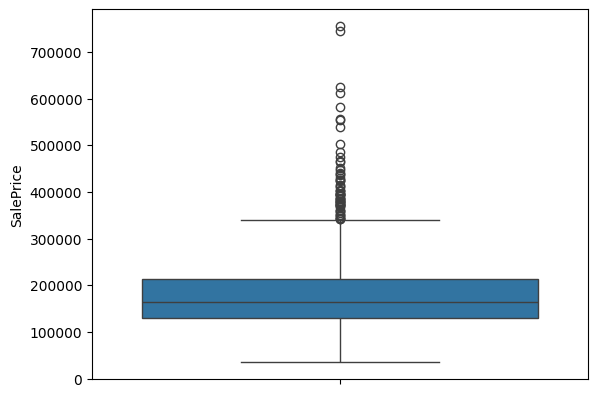

In [ ]:
# Let's try plotting a box plot to visualize the outliers in the SalePrice
outlier_detection_data = df["SalePrice"]
snsb.boxplot(outlier_detection_data)

## **OUTLIER ANALYSIS**

In [ ]:
pd.set_option('display.max_columns', None)
high_priced_houses = df[df['SalePrice'] > 700000]
high_priced_houses

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice,TotalSF,TotalBath,HouseAgeAtSale,YearsSinceRemodel,GarageAge,TotalPorchSF,Remodeled
691,60,RL,104.0,21535,Pave,IR1,Lvl,AllPub,Corner,Gtl,NoRidge,Norm,Norm,1Fam,2Story,10,6,1994,1995,Gable,WdShngl,HdBoard,HdBoard,BrkFace,1170.0,Ex,TA,PConc,Ex,TA,Gd,GLQ,1455,Unf,0,989,2444,GasA,Ex,Y,SBrkr,2444,1872,0,4316,0,1,3,1,4,1,Ex,10,Typ,2,Ex,Attchd,1994.0,Fin,3,832,TA,TA,Y,382,50,0,0,0,0,0,1,2007,WD,Normal,755000,6760,4.0,13,12,13.0,50,1
1182,60,RL,160.0,15623,Pave,IR1,Lvl,AllPub,Corner,Gtl,NoRidge,Norm,Norm,1Fam,2Story,10,5,1996,1996,Hip,CompShg,Wd Sdng,ImStucc,None,0.0,Gd,TA,PConc,Ex,TA,Av,GLQ,2096,Unf,0,300,2396,GasA,Ex,Y,SBrkr,2411,2065,0,4476,1,0,3,1,4,1,Ex,10,Typ,2,TA,Attchd,1996.0,Fin,3,813,TA,TA,Y,171,78,0,0,0,555,0,7,2007,WD,Abnorml,745000,6872,4.5,11,11,11.0,78,0


In [ ]:
pd.set_option('display.max_columns', None)
high_priced_houses = df[(df['SalePrice'] < 500000) & (df['SalePrice'] > 400000)]
high_priced_houses.head(2)

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice,TotalSF,TotalBath,HouseAgeAtSale,YearsSinceRemodel,GarageAge,TotalPorchSF,Remodeled
58,60,RL,66.0,13682,Pave,IR2,HLS,AllPub,CulDSac,Gtl,StoneBr,Norm,Norm,1Fam,2Story,10,5,2006,2006,Hip,CompShg,VinylSd,VinylSd,BrkFace,1031.0,Ex,TA,PConc,Ex,TA,Gd,Unf,0,Unf,0,1410,1410,GasA,Ex,Y,SBrkr,1426,1519,0,2945,0,0,3,1,3,1,Gd,10,Typ,1,Gd,BuiltIn,2006.0,Fin,3,641,TA,TA,Y,192,0,37,0,0,0,0,10,2006,New,Partial,438780,4355,3.5,0,0,0.0,37,0
161,60,RL,110.0,13688,Pave,IR1,Lvl,AllPub,Inside,Gtl,NridgHt,Norm,Norm,1Fam,2Story,9,5,2003,2004,Gable,CompShg,VinylSd,VinylSd,BrkFace,664.0,Gd,TA,PConc,Ex,TA,Av,GLQ,1016,Unf,0,556,1572,GasA,Ex,Y,SBrkr,1572,1096,0,2668,1,0,2,1,3,1,Ex,10,Typ,2,Gd,BuiltIn,2003.0,Fin,3,726,TA,TA,Y,400,0,0,0,0,0,0,3,2008,WD,Normal,412500,4240,3.5,5,4,5.0,0,1


In [ ]:
#Dropping the Outliers
#df = df.drop(df[df['SalePrice'] > 700000].index)

## **SCATTER PLOT VISUALIZATION (GrLivArea vs SalePrice)**

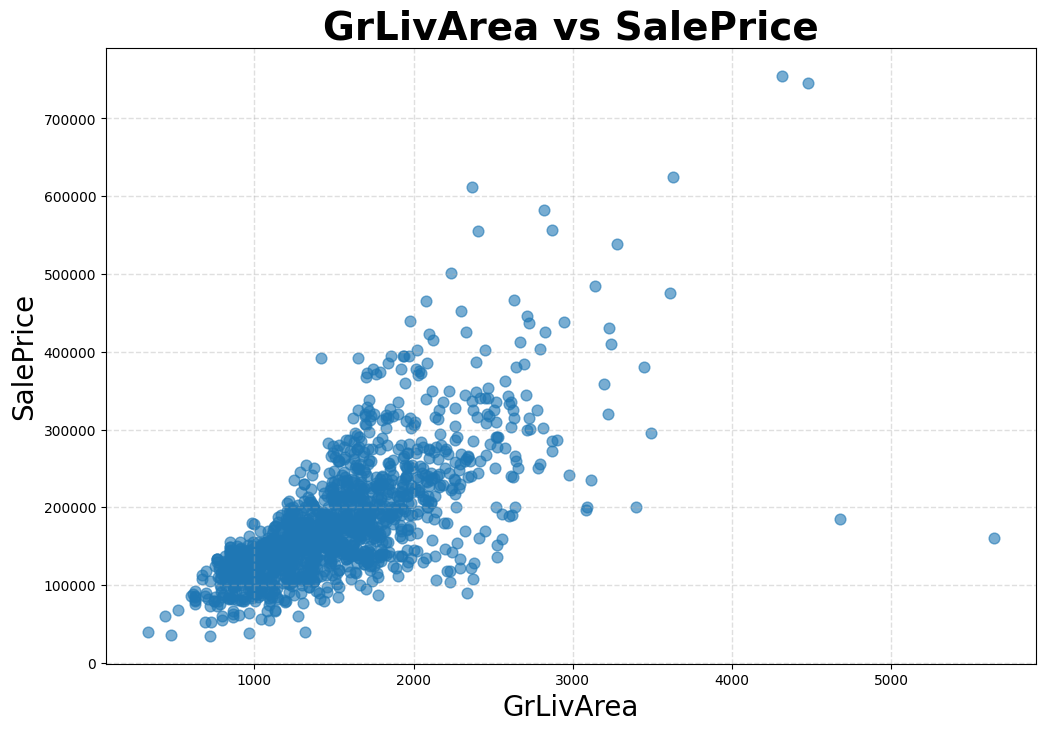

In [ ]:
plt.figure(figsize=(12, 8))
plt.scatter(df['GrLivArea'], df['SalePrice'], alpha=0.6, s=60)

plt.title("GrLivArea vs SalePrice", fontsize=28, fontweight='bold')
plt.xlabel("GrLivArea", fontsize=20)
plt.ylabel("SalePrice", fontsize=20)

plt.grid(True, linestyle='--', linewidth=1, alpha=0.4)
plt.show()


In [ ]:
pd.set_option('display.max_columns', None)
high_priced_houses = df[(df['GrLivArea'] > 4000) & (df['SalePrice'] < 300000)]
high_priced_houses

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice,TotalSF,TotalBath,HouseAgeAtSale,YearsSinceRemodel,GarageAge,TotalPorchSF,Remodeled
523,60,RL,130.0,40094,Pave,IR1,Bnk,AllPub,Inside,Gtl,Edwards,PosN,PosN,1Fam,2Story,10,5,2007,2008,Hip,CompShg,CemntBd,CmentBd,Stone,762.0,Ex,TA,PConc,Ex,TA,Gd,GLQ,2260,Unf,0,878,3138,GasA,Ex,Y,SBrkr,3138,1538,0,4676,1,0,3,1,3,1,Ex,11,Typ,1,Gd,BuiltIn,2007.0,Fin,3,884,TA,TA,Y,208,406,0,0,0,0,0,10,2007,New,Partial,184750,7814,4.5,0,-1,0.0,406,1
1298,60,RL,313.0,63887,Pave,IR3,Bnk,AllPub,Corner,Gtl,Edwards,Feedr,Norm,1Fam,2Story,10,5,2008,2008,Hip,ClyTile,Stucco,Stucco,Stone,796.0,Ex,TA,PConc,Ex,TA,Gd,GLQ,5644,Unf,0,466,6110,GasA,Ex,Y,SBrkr,4692,950,0,5642,2,0,2,1,3,1,Ex,12,Typ,3,Gd,Attchd,2008.0,Fin,2,1418,TA,TA,Y,214,292,0,0,0,480,0,1,2008,New,Partial,160000,11752,4.5,0,0,0.0,292,0


The first and last rows are dropped because they represent properties that are exceptionally large but sold for a price below what the market expects. They likely represent non-market transactions

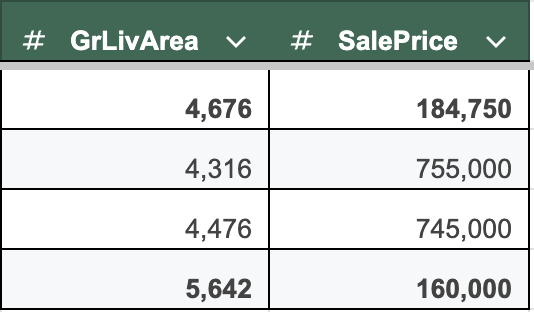

## **DROPPING THE OUTLIERS**

In [ ]:
print(f"Shape before outlier removal: {df.shape}")
outliers = df[(df['GrLivArea'] > 4000) & (df['SalePrice'] < 300000)].index
df = df.drop(outliers)
print(f"Shape after outlier removal: {df.shape}")

Shape before outlier removal: (1460, 83)
Shape after outlier removal: (1458, 83)


# **VISUALIZING DISTRIBUTION PLOTS FOR NUMERIC FEATURES BEFORE AND AFTER LOG TRANSFORMATION**

These plots show the distribution of the most skewed numeric features before and after transformation. The log1p transformation helps reduce right-skewness in continuous variables, making them more suitable for modeling. This step ensures numerical stability and improves model performance during regression-based learning.

Top numeric features used for distribution visualization: ['MiscVal', 'PoolArea', 'LotArea', '3SsnPorch', 'LowQualFinSF', 'KitchenAbvGr', 'BsmtFinSF2', 'ScreenPorch', 'BsmtHalfBath', 'GarageYrBlt', 'EnclosedPorch', 'MasVnrArea', 'OpenPorchSF', 'TotalPorchSF', 'LotFrontage', 'WoodDeckSF', 'MSSubClass', 'GrLivArea']


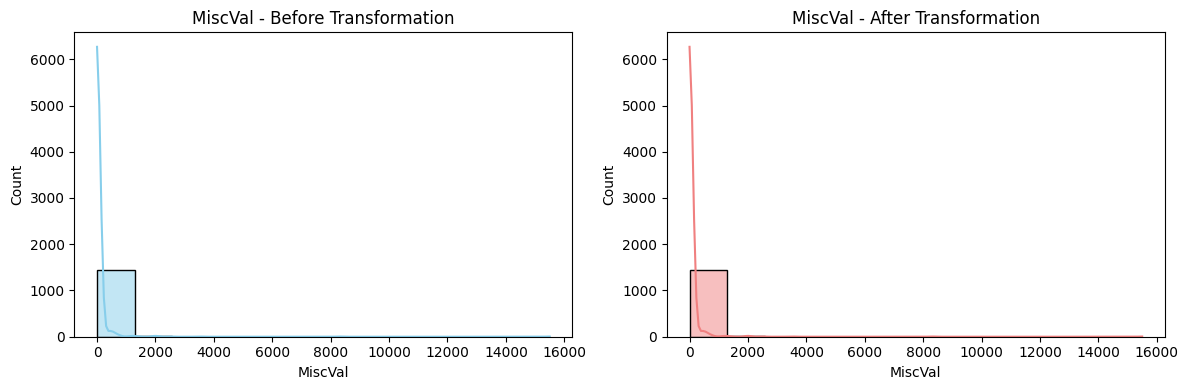

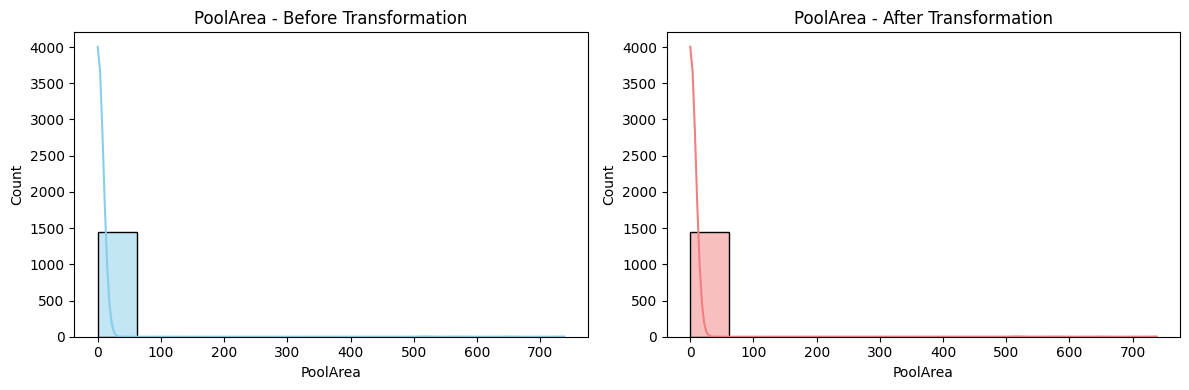

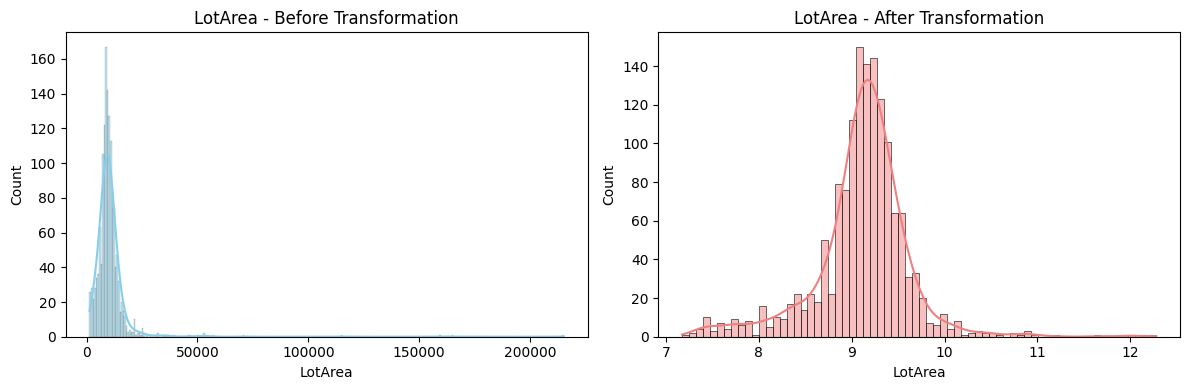

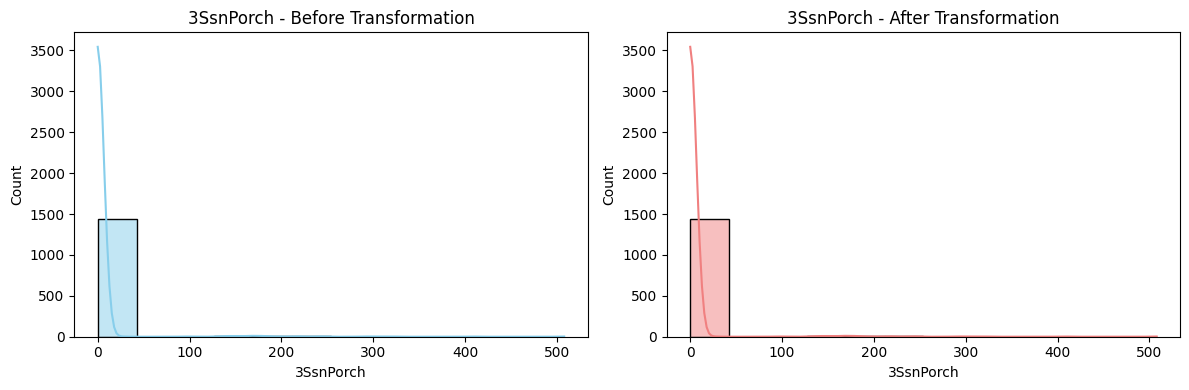

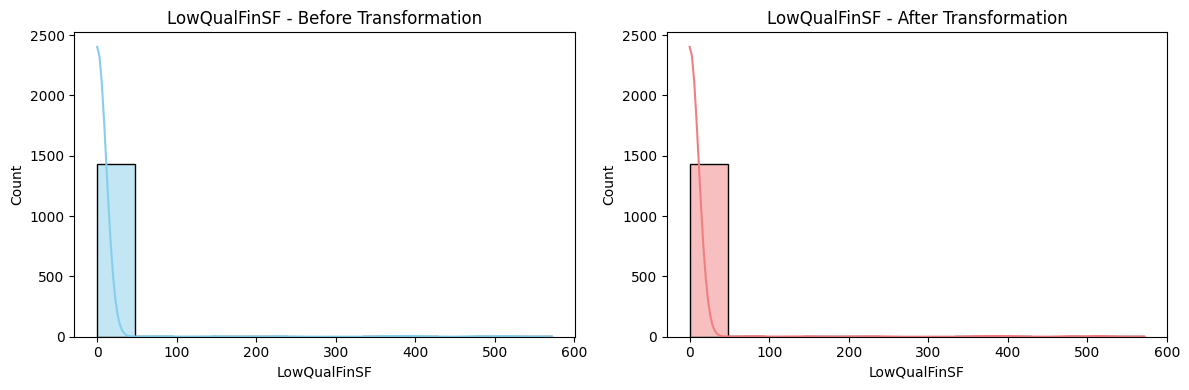

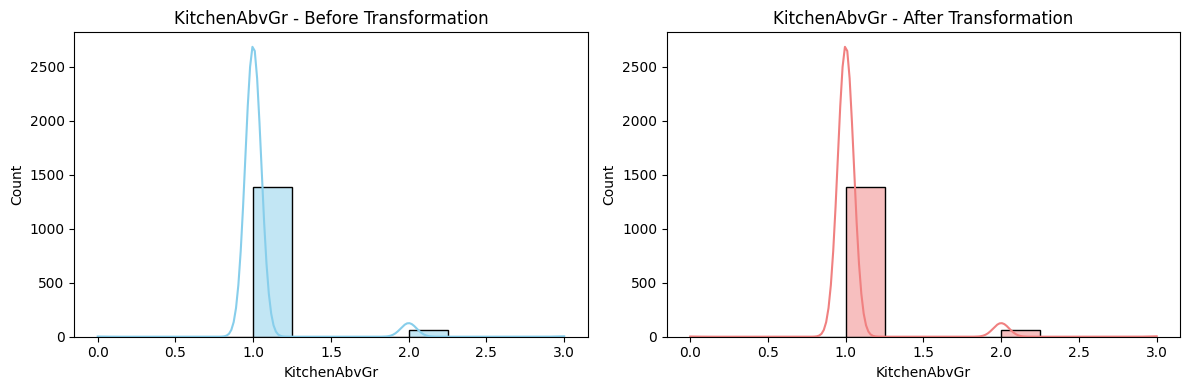

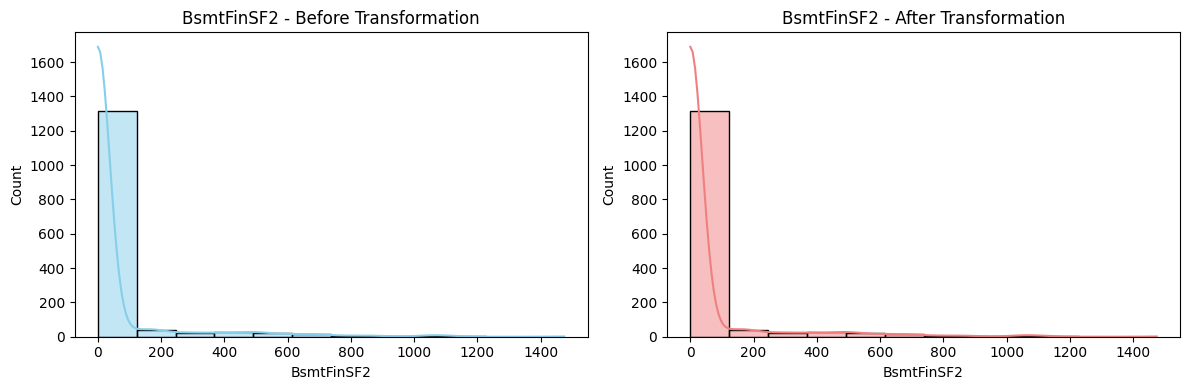

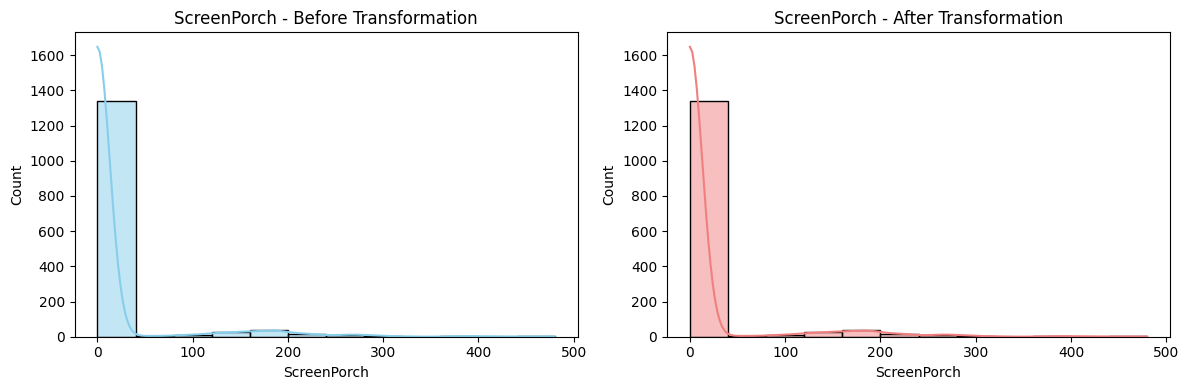

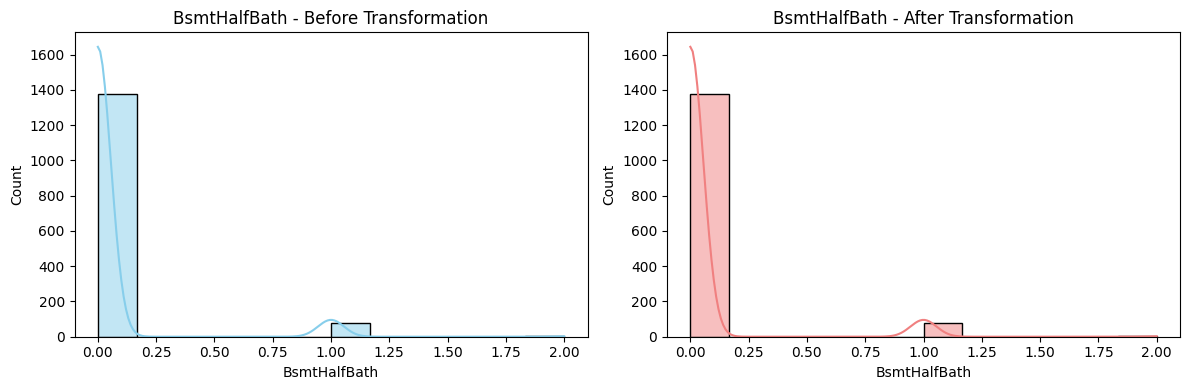

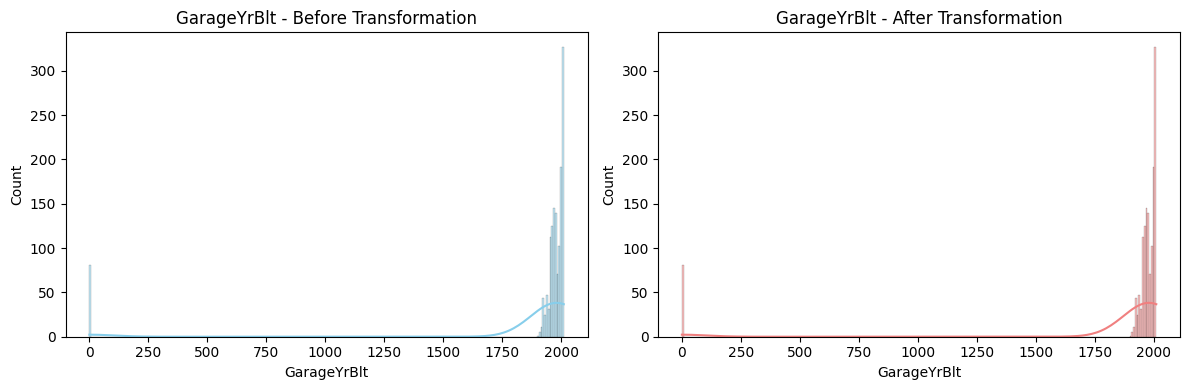

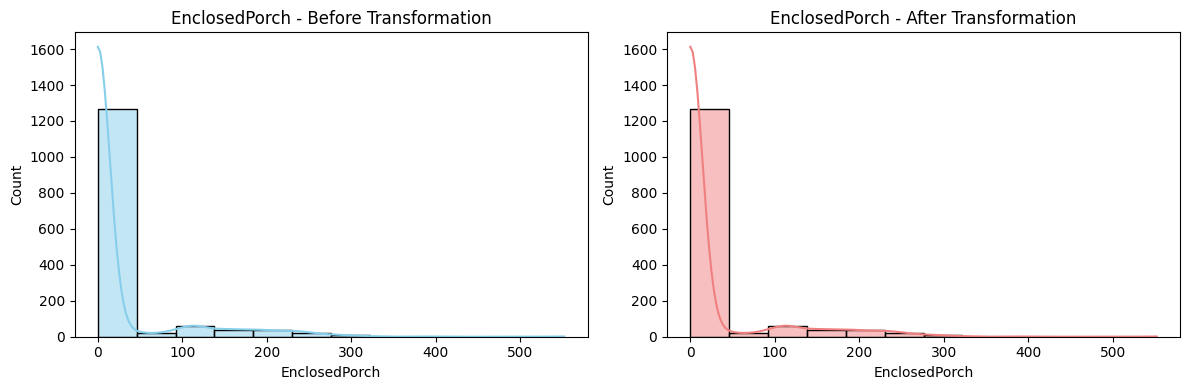

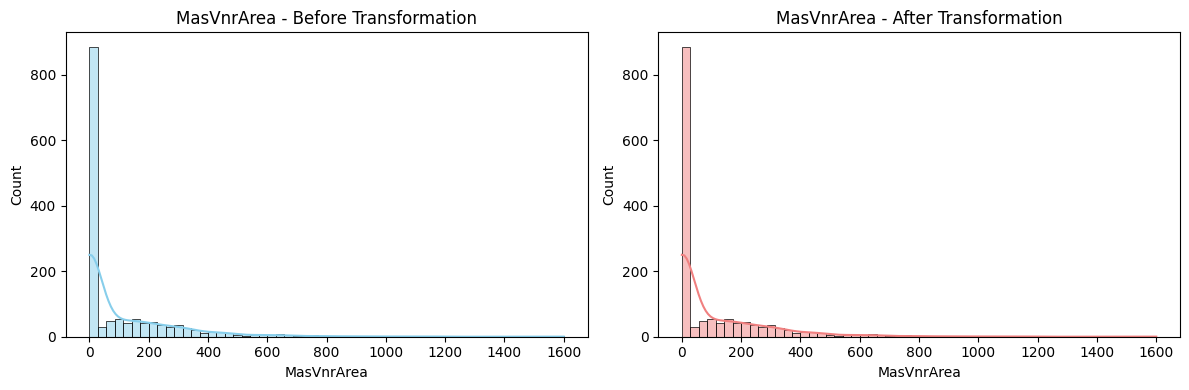

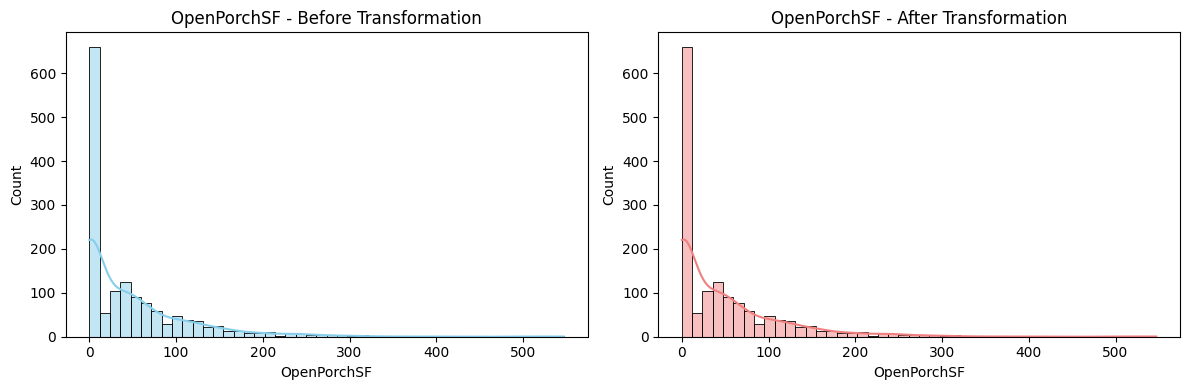

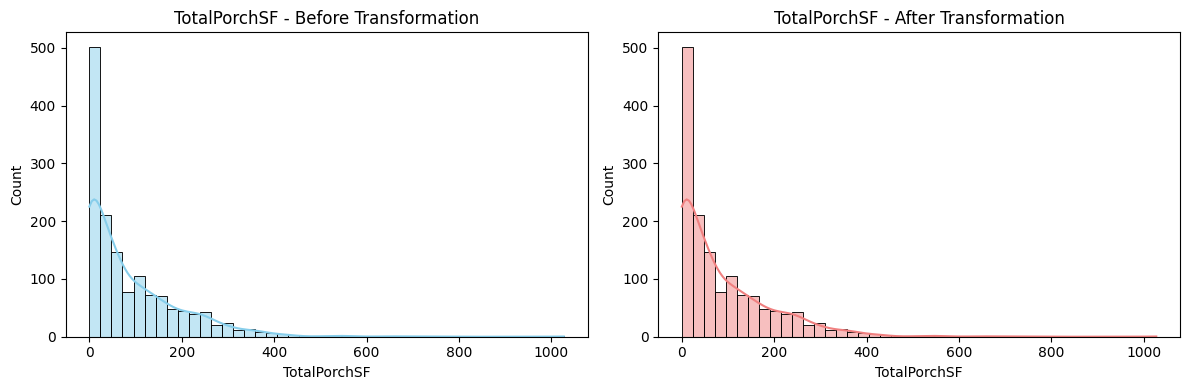

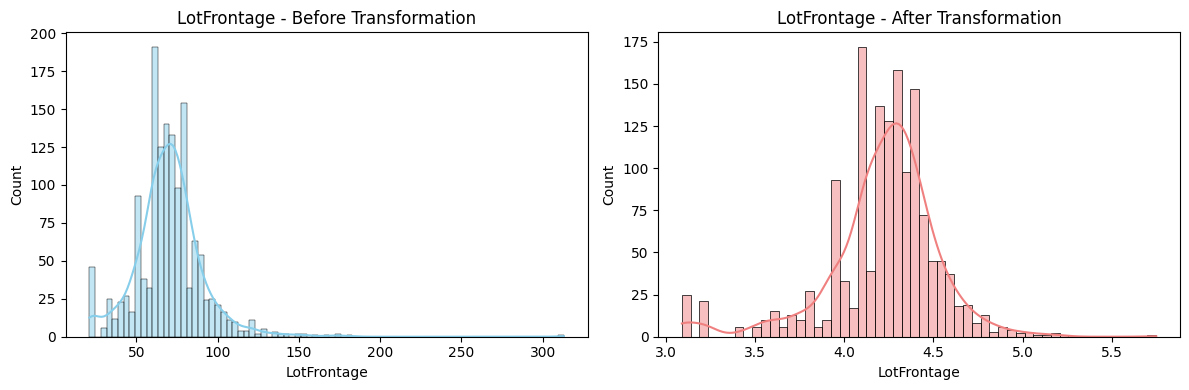

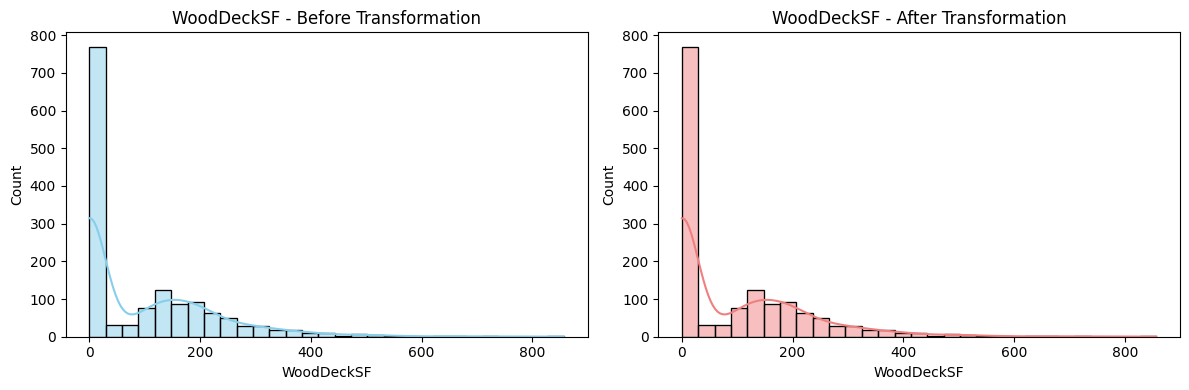

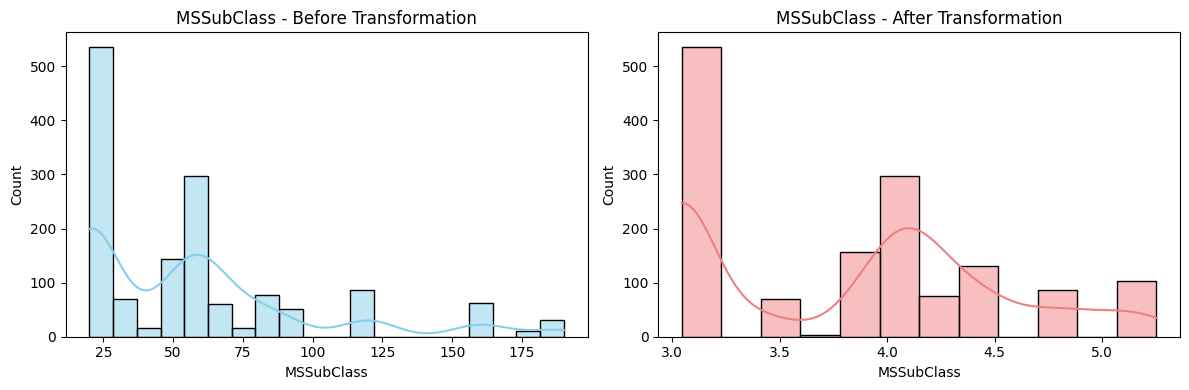

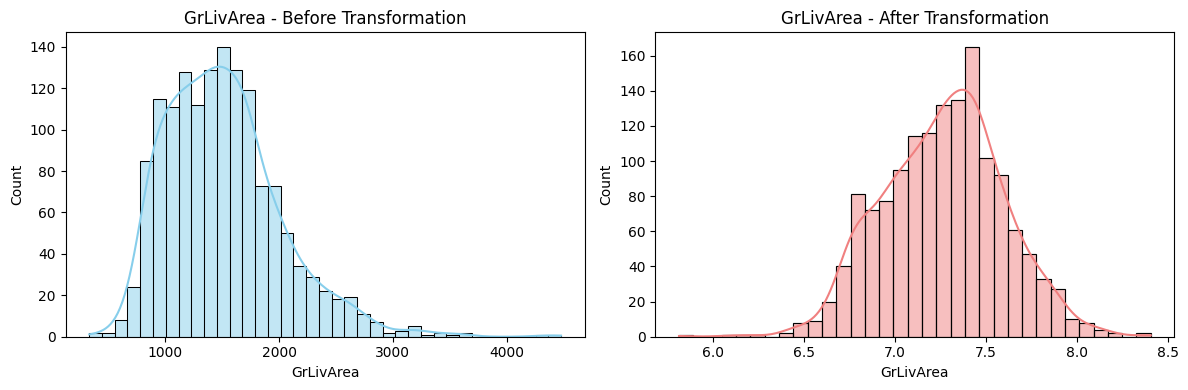

In [ ]:
# Select all numeric columns
numeric_features = df.select_dtypes(include=['int64', 'float64']).columns

# Do NOT touch the target when fixing skewness
numeric_features = numeric_features.drop('SalePrice')

# Compute skewness of each numeric column
skewness = df[numeric_features].apply(lambda x: skew(x.dropna()))
skewness = skewness.abs().sort_values(ascending=False)

# Pick top 5 most skewed numeric features
# top_features = list(skewness.head(5).index)

# Focus on ALL strongly skewed numeric features (|skew| > 1.0)
skewed_feats = skewness[skewness > 1.0]
top_features = list(skewed_feats.index)


print("Top numeric features used for distribution visualization:", top_features)

# Plot distributions before and after log1p transformation
for feature in top_features:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Plot original distribution
    snsb.histplot(df[feature], kde=True, ax=axes[0], color='skyblue')
    axes[0].set_title(f"{feature} - Before Transformation")

    # Apply log1p transformation if data is positive and skewed
    if (df[feature] > 0).all():
        transformed = np.log1p(df[feature])
    else:
        transformed = df[feature]

    snsb.histplot(transformed, kde=True, ax=axes[1], color='lightcoral')
    axes[1].set_title(f"{feature} - After Transformation")

    plt.tight_layout()
    plt.show()

# Apply transforms back to df
for col in top_features:
    if (df[col] > 0).all() and df[col].skew() > 1:
        df[col] = np.log1p(df[col])

# **CORRELATION ANALYSIS OF NUMERIC COLUMNS WITH SALEPRICE**

Top correlated numeric features with SalePrice:


,SalePrice
SalePrice,1.000000
TotalSF,0.832877
OverallQual,0.795774
GrLivArea,0.702933
TotalBsmtSF,0.651153
GarageCars,0.641047
TotalBath,0.635896
1stFlrSF,0.631530
GarageArea,0.629217
FullBath,0.562165


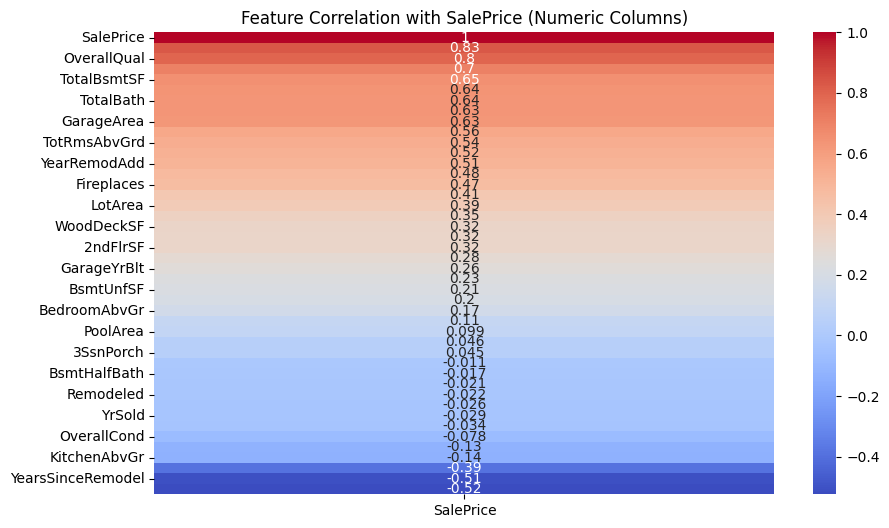

In [ ]:
# Select only numeric columns to avoid errors with string data
numeric_df = df.select_dtypes(include=['int64', 'float64'])

# Compute correlation of numeric features with SalePrice
corr_with_target = numeric_df.corr()['SalePrice'].sort_values(ascending=False)

# Display top 10 correlated features
print("Top correlated numeric features with SalePrice:")
display(corr_with_target.head(10))

# Optional heatmap visualization
plt.figure(figsize=(10,6))
snsb.heatmap(numeric_df.corr()[['SalePrice']].sort_values(by='SalePrice', ascending=False),
             annot=True, cmap='coolwarm')
plt.title('Feature Correlation with SalePrice (Numeric Columns)')
plt.show()

# **CHECKING SKEWNESS ON SALESPRICE COLUMN (BEFORE)**

Skewness before transformation: 1.8793604459195012


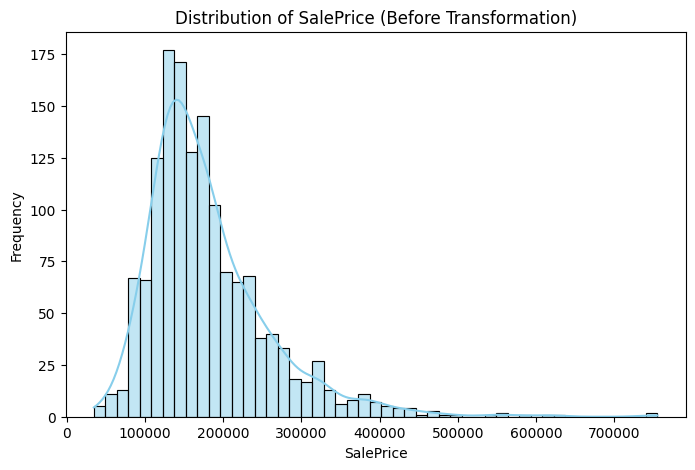

In [ ]:
print(f"Skewness before transformation: {skew(df['SalePrice'])}")

# Plot histogram and distribution
plt.figure(figsize=(8,5))
snsb.histplot(df['SalePrice'], kde=True, color='skyblue')
plt.title("Distribution of SalePrice (Before Transformation)")
plt.xlabel("SalePrice")
plt.ylabel("Frequency")
plt.show()

In [ ]:
# Transform target
df['SalePrice'] = np.log1p(df['SalePrice'])
#y = np.log1p(df["SalePrice"])

# **CHECKING SKEWNESS ON SALESPRICE COLUMN (AFTER)**

Skewness after log transformation: 0.12145464268184528


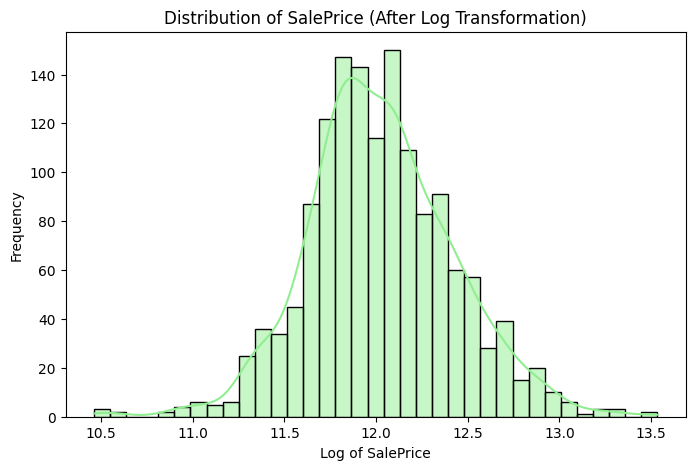

In [ ]:
print(f"Skewness after log transformation: {skew(df['SalePrice'])}")

plt.figure(figsize=(8,5))
snsb.histplot(df['SalePrice'], kde=True, color='lightgreen')
plt.title("Distribution of SalePrice (After Log Transformation)")
plt.xlabel("Log of SalePrice")
plt.ylabel("Frequency")
plt.show()

# **TEXT-BASED COMPOSITE FEATURE + VECTORIZATION**

In [ ]:
text_cols = ['Neighborhood', 'HouseStyle', 'SaleCondition']

# Create a single combined text column
df['CombinedText'] = (
    df['Neighborhood'].astype(str) + ' ' +
    df['HouseStyle'].astype(str) + ' ' +
    df['SaleCondition'].astype(str)
)

# Vectorize the combined text using CountVectorizer
# (we limit to top 50 tokens to avoid too many sparse features)
vectorizer = CountVectorizer(max_features=50)
text_matrix = vectorizer.fit_transform(df['CombinedText'])

# Convert sparse matrix to DataFrame aligned with df
text_df = pd.DataFrame(
    text_matrix.toarray(),
    columns=[f"text_{t}" for t in vectorizer.get_feature_names_out()],
    index=df.index
)

# Join the new text features back to df
df = pd.concat([df, text_df], axis=1)

# Drop the raw text column so it doesn't get one-hot encoded again
df.drop(columns=['CombinedText'], inplace=True)


# **APPLYING ONE-HOT ENCODING ON ALL COLUMN EXCLUDING TARGET VARIABLE (SALEPRICE)**

In [ ]:
X = pd.get_dummies(df.drop(columns=['SalePrice']), drop_first=True) #This drops the column named "SalePrice" from the DataFrame df.
                                        #"SalePrice" is dropped because it is the value you are trying to predict (the target).
# X = df.drop("SalePrice", axis=1)

y = df["SalePrice"]             #y now contains only the actual house prices, which is the single
                                 #value the model is trained to predict based on the features in X.


In [ ]:
# The core reason this line is required is to convert categorical features
# (columns with non-numeric text, like 'MSZoning' with values 'RL', 'FV', etc.) into a format
# that a mathematical model can process: numerical data.

# The drop_first=True argument prevents a statistical problem known as
# multicollinearity (or the "dummy variable trap").
# For a feature with N categories, it creates N new binary columns.
# Since the value of the Nth column can be perfectly predicted if you know the
# values of the first N−1 columns (i.e., if all N−1 columns are 0, the N th
# category must be 1), this perfect correlation can cause issues in some models.
# Dropping one column avoids this perfect dependency without losing any information.

# **EXTRACTING FEATURE iMPORTANCE USING RANDOM FOREST REGRESSOR**

| Task Type          | Example Target                                 | Model to Use             | Output                   |
| ------------------ | ---------------------------------------------- | ------------------------ | ------------------------ |
| **Regression**     | House prices, temperature, salary              | `RandomForestRegressor`  | Continuous numeric value |
| **Classification** | Fraud detection, sentiment (positive/negative) | `RandomForestClassifier` | Discrete class label     |


In [ ]:
# using all data for feature importance
model = RandomForestRegressor(n_estimators=200, random_state=42, max_depth=15, min_samples_split=5)
model.fit(X, y)

importances = pd.Series(model.feature_importances_, index=X.columns)
importances_percent = (importances / importances.sum()) * 100 # Get feature importances as percentages

# Method 1
# top_features = importances_percent.sort_values(ascending=False).head(50)
# print(top_features)

# Method 2
cumulative = importances_percent.sort_values(ascending=False).cumsum()
n_features_95 = (cumulative <= 95).sum()
print(f"Features for 95% importance: {n_features_95}")
top_features = importances_percent.sort_values(ascending=False).head(n_features_95)
print(f"\nUsing {len(top_features)} features")
print(f"Total importance captured: {top_features.sum():.2f}%")


Features for 95% importance: 31

Using 31 features
Total importance captured: 94.93%


# **VISUALIZING THE IMPORTANT FEATURES**

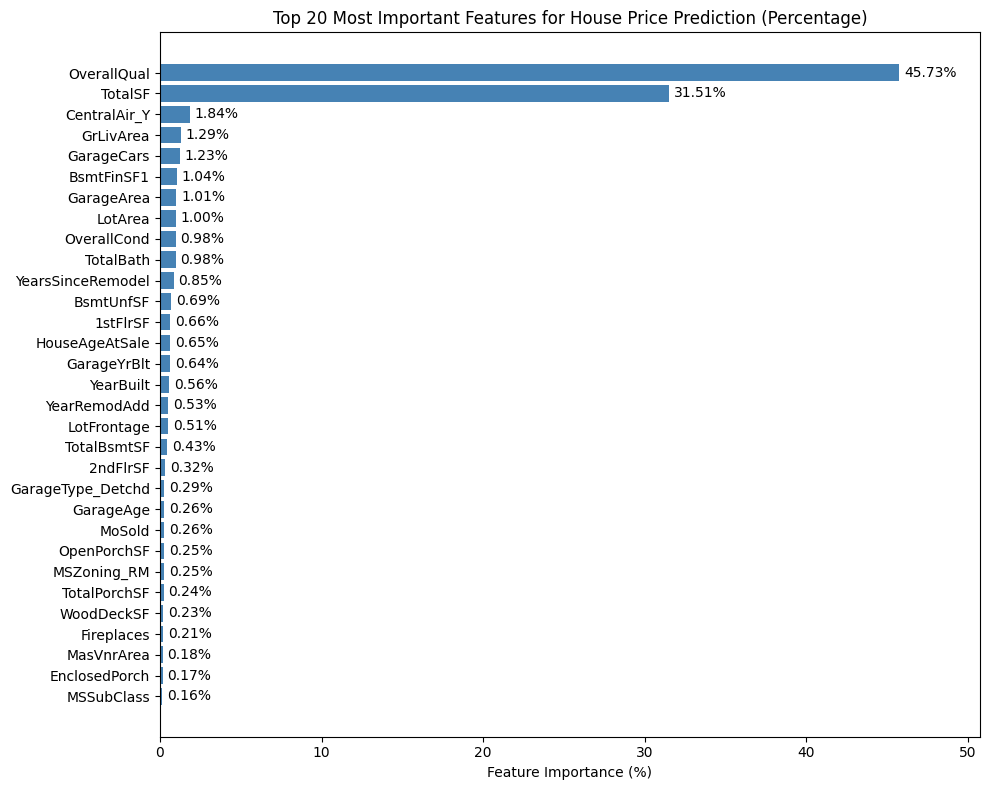

In [ ]:
# Plot horizontal bar chart with matching values and labels
plt.figure(figsize=(10, 8))
bars = plt.barh(top_features.index, top_features, color='steelblue')

# Add percentage labels at the end of each bar
for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.3, bar.get_y() + bar.get_height()/2,
             f'{width:.2f}%', va='center')

plt.title("Top 20 Most Important Features for House Price Prediction (Percentage)")
plt.xlabel("Feature Importance (%)")
plt.xlim(0, top_features.max() + 5)  # ensures the chart fits the labels perfectly
plt.gca().invert_yaxis()  # highest importance on top
plt.tight_layout()
plt.show()

# **VISUALIZING A HEAT MAP TO DETERMINE THE CORRELATION BETWEEN THE FEATURES (BEFORE)**

Correlation heatmaps reveal redundant variables (highly correlated columns).

Features with correlation >0.8 are dropped to avoid multicollinearity.

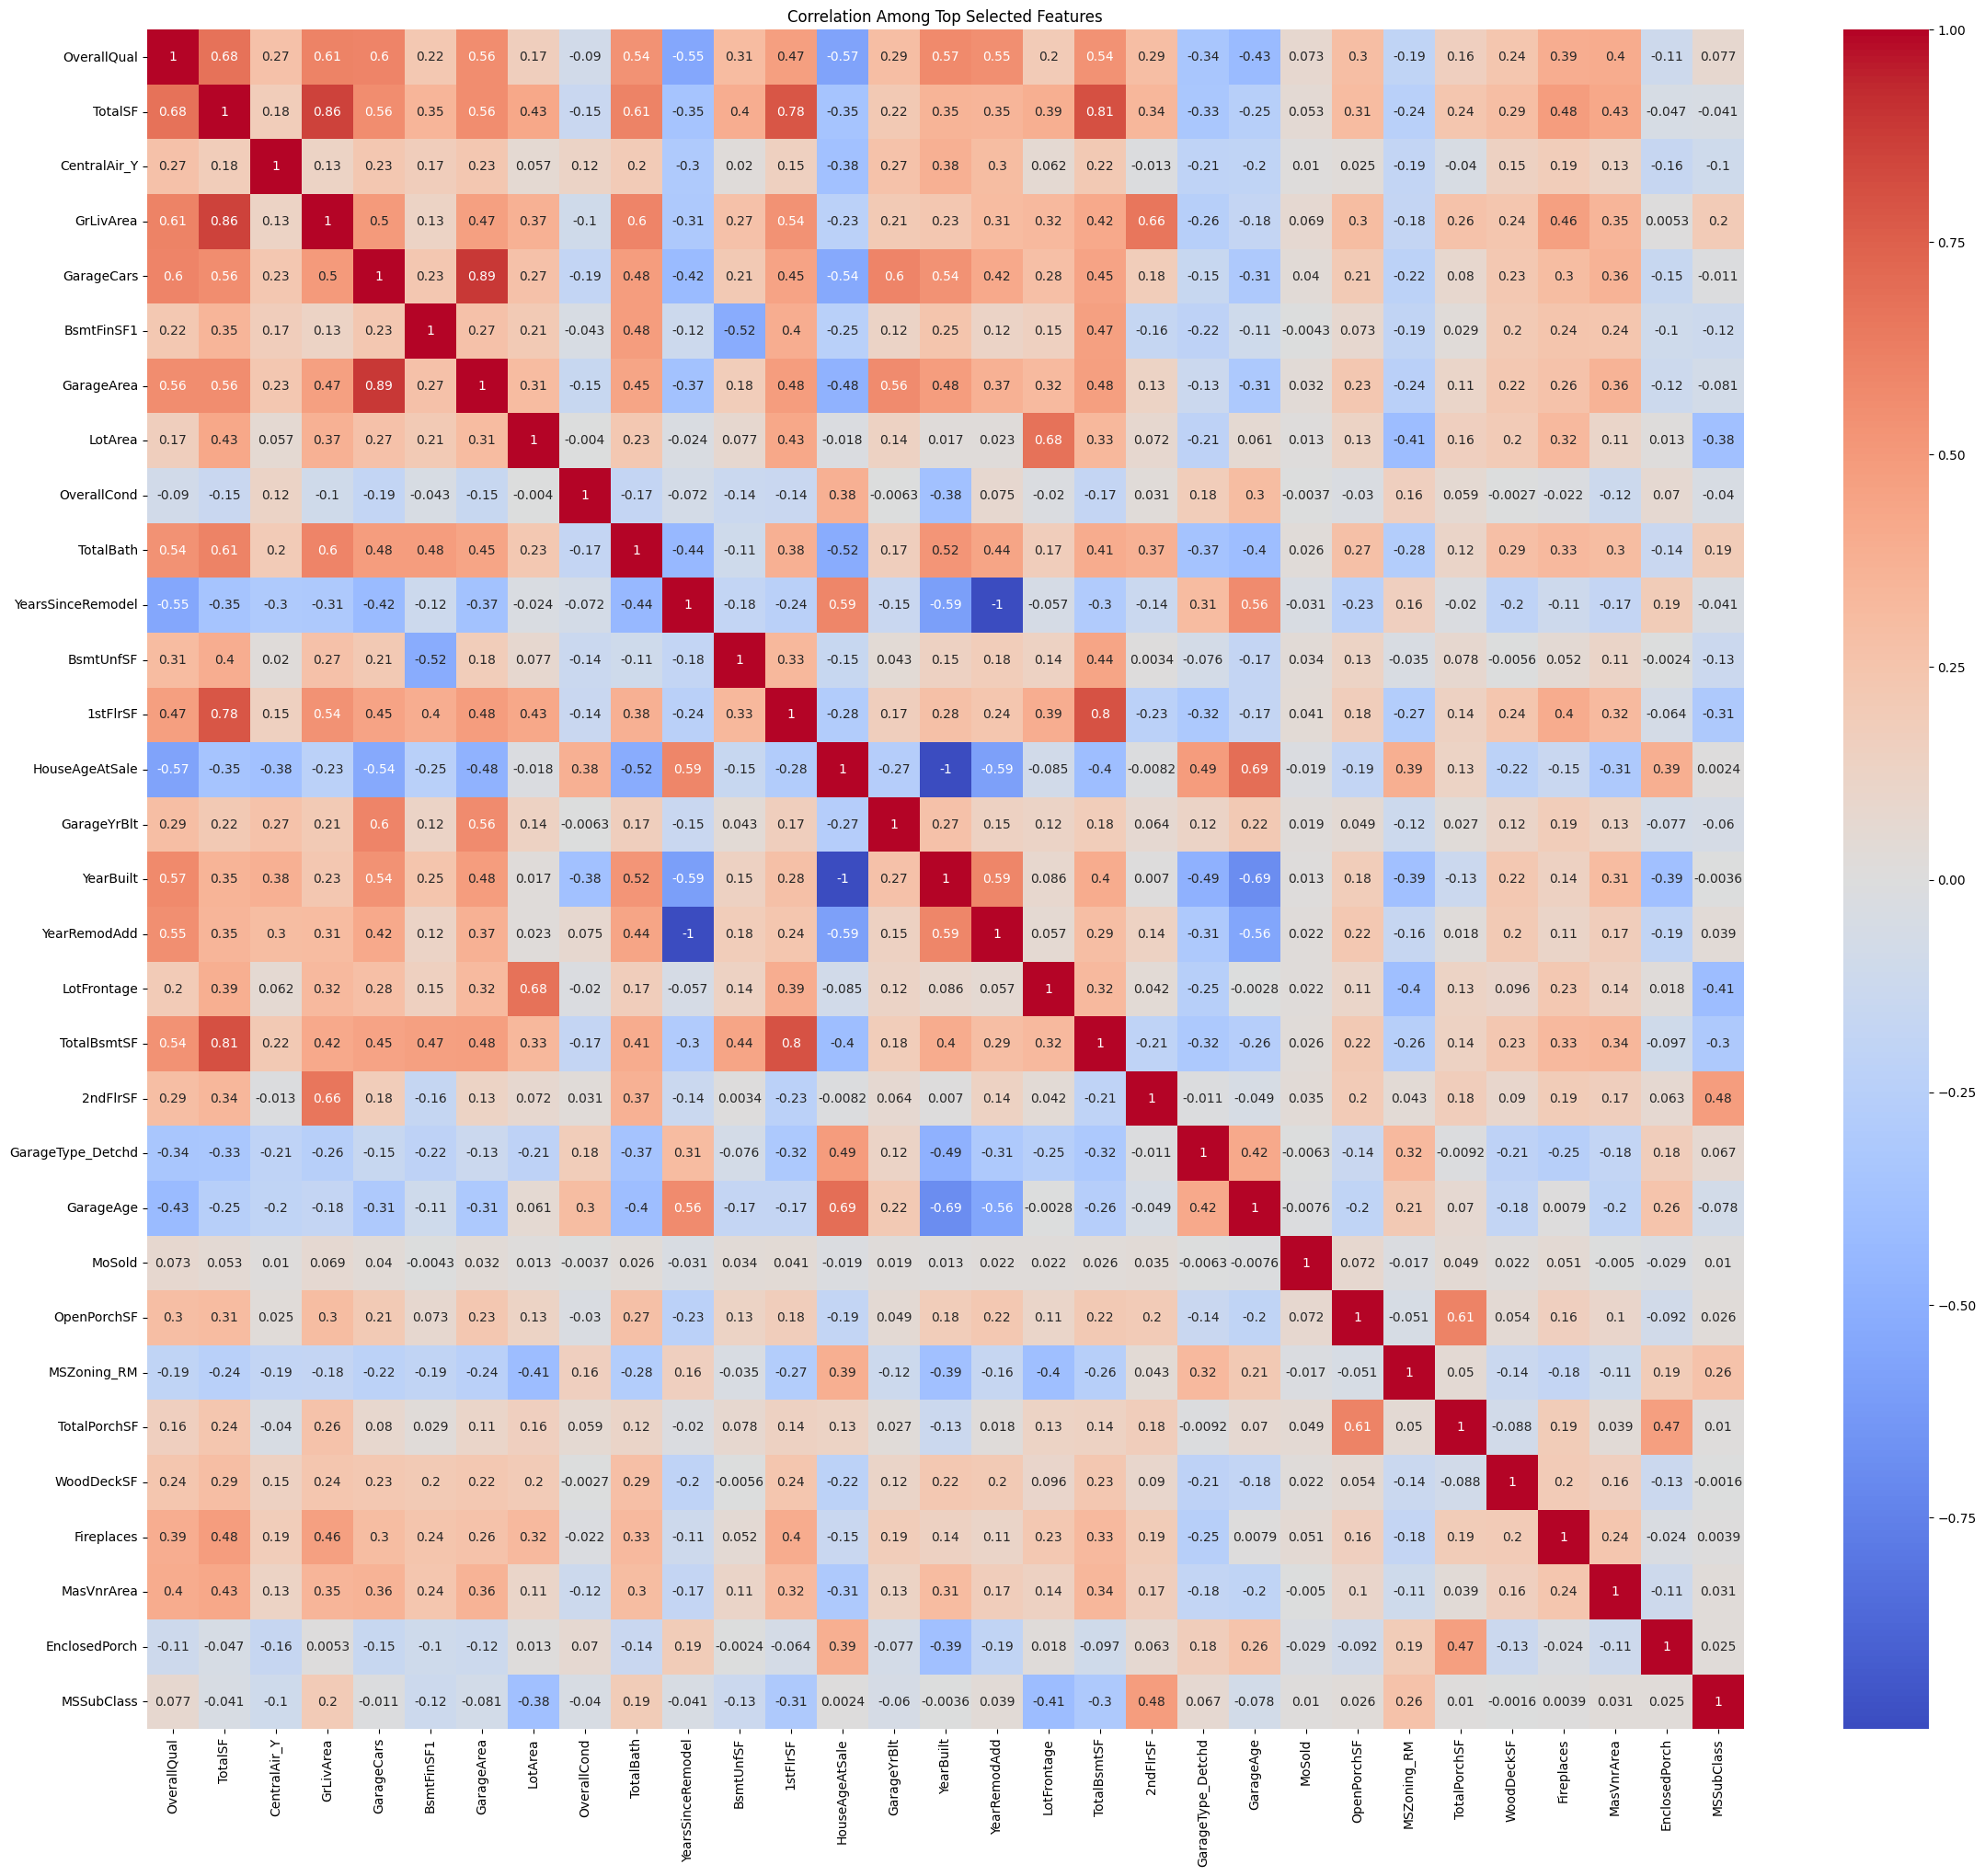

In [ ]:
top_corr_features = X[top_features.index]
plt.figure(figsize=(28,24))
snsb.heatmap(top_corr_features.corr(), cmap='coolwarm', annot=True)
plt.title("Correlation Among Top Selected Features")
plt.show()

In [ ]:
top_corr_features = top_corr_features.drop(columns=['GarageCars', 'GarageYrBlt', 'OpenPorchSF'])

# **APPLYING VIF (VARIANCE INFLATION FACTOR) TO REDUCE MULTICOLINEARITY**

In [ ]:
# Standardize the features
X_scaled = StandardScaler().fit_transform(X[top_corr_features.columns])

# Convert back to DataFrame
X_scaled_df = pd.DataFrame(X_scaled, columns=top_corr_features.columns)

# Add constant for intercept term
X_const = add_constant(X_scaled_df)

# Compute VIF for each feature
vif_data = pd.DataFrame()
vif_data['Feature'] = X_const.columns
vif_data['VIF'] = [variance_inflation_factor(X_const.values, i)
                   for i in range(X_const.shape[1])]

# Display the VIF table
print(vif_data)
vif_data = vif_data[vif_data['Feature'] != 'const']

              Feature        VIF
0               const   1.000000
1         OverallQual   3.054586
2             TotalSF        inf
3        CentralAir_Y   1.385026
4           GrLivArea  19.620211
5          BsmtFinSF1   8.319307
6          GarageArea   2.063098
7             LotArea   2.467824
8         OverallCond   1.690406
9           TotalBath   3.151267
10  YearsSinceRemodel        inf
11          BsmtUnfSF   8.554406
12           1stFlrSF        inf
13     HouseAgeAtSale        inf
14          YearBuilt        inf
15       YearRemodAdd        inf
16        LotFrontage   2.197996
17        TotalBsmtSF        inf
18           2ndFlrSF        inf
19  GarageType_Detchd   1.696862
20          GarageAge   2.338288
21             MoSold   1.037788
22        MSZoning_RM   1.581233
23       TotalPorchSF   1.509976
24         WoodDeckSF   1.215651
25         Fireplaces   1.541141
26         MasVnrArea   1.368942
27      EnclosedPorch   1.544900
28         MSSubClass   2.015224


/usr/local/lib/python3.12/dist-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


In [ ]:
vif_threshold = 10

# Get the features with high VIF
high_vif_features = vif_data[vif_data['VIF'] > vif_threshold]['Feature']
print("Features with high VIF:\n", high_vif_features.tolist())

Features with high VIF:
 ['TotalSF', 'GrLivArea', 'YearsSinceRemodel', '1stFlrSF', 'HouseAgeAtSale', 'YearBuilt', 'YearRemodAdd', 'TotalBsmtSF', '2ndFlrSF']


In [ ]:
# Filter out infinite VIFs explicitly
inf_vif_features = vif_data[vif_data['VIF'] == float('inf')]['Feature']

# Combine with high-VIF features
all_bad_vif_features = pd.concat([high_vif_features, inf_vif_features]).unique()

print("Features with Infinite VIF:\n", list(all_bad_vif_features))


Features with Infinite VIF:
 ['TotalSF', 'GrLivArea', 'YearsSinceRemodel', '1stFlrSF', 'HouseAgeAtSale', 'YearBuilt', 'YearRemodAdd', 'TotalBsmtSF', '2ndFlrSF']


# **DROPPING HIGH VIF FEATURES FROM SELECTED FEATURES**

In [ ]:
X_reduced = top_corr_features.drop(columns=all_bad_vif_features)
X_reduced

,OverallQual,CentralAir_Y,BsmtFinSF1,GarageArea,LotArea,OverallCond,TotalBath,BsmtUnfSF,LotFrontage,GarageType_Detchd,GarageAge,MoSold,MSZoning_RM,TotalPorchSF,WoodDeckSF,Fireplaces,MasVnrArea,EnclosedPorch,MSSubClass
0,7,True,706,548,9.042040,5,3.5,150,4.189655,False,5.0,2,False,61,0,0,196.0,0,4.110874
1,6,True,978,460,9.169623,8,2.5,284,4.394449,False,31.0,5,False,0,298,1,0.0,0,3.044522
2,7,True,486,608,9.328212,5,3.5,434,4.234107,False,7.0,9,False,42,0,1,162.0,0,4.110874
3,7,True,216,642,9.164401,5,2.0,540,4.110874,True,8.0,2,False,307,0,1,0.0,272,4.262680
4,8,True,655,836,9.565284,5,3.5,490,4.442651,False,8.0,12,False,84,192,1,350.0,0,4.110874
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,6,True,0,460,8.976894,5,2.5,953,4.143135,False,8.0,8,False,40,0,1,0.0,0,4.110874
1456,6,True,790,500,9.486152,6,3.0,589,4.454347,False,32.0,2,False,0,349,2,119.0,0,3.044522
1457,7,True,275,252,9.109746,9,2.0,877,4.204693,False,69.0,5,False,60,0,2,0.0,0,4.262680
1458,5,True,49,240,9.181735,6,2.0,0,4.234107,False,60.0,4,False,112,366,0,0.0,112,3.044522


# **VISUALIZING A HEAT MAP TO DETERMINE THE CORRELATION BETWEEN THE FEATURES (AFTER)**

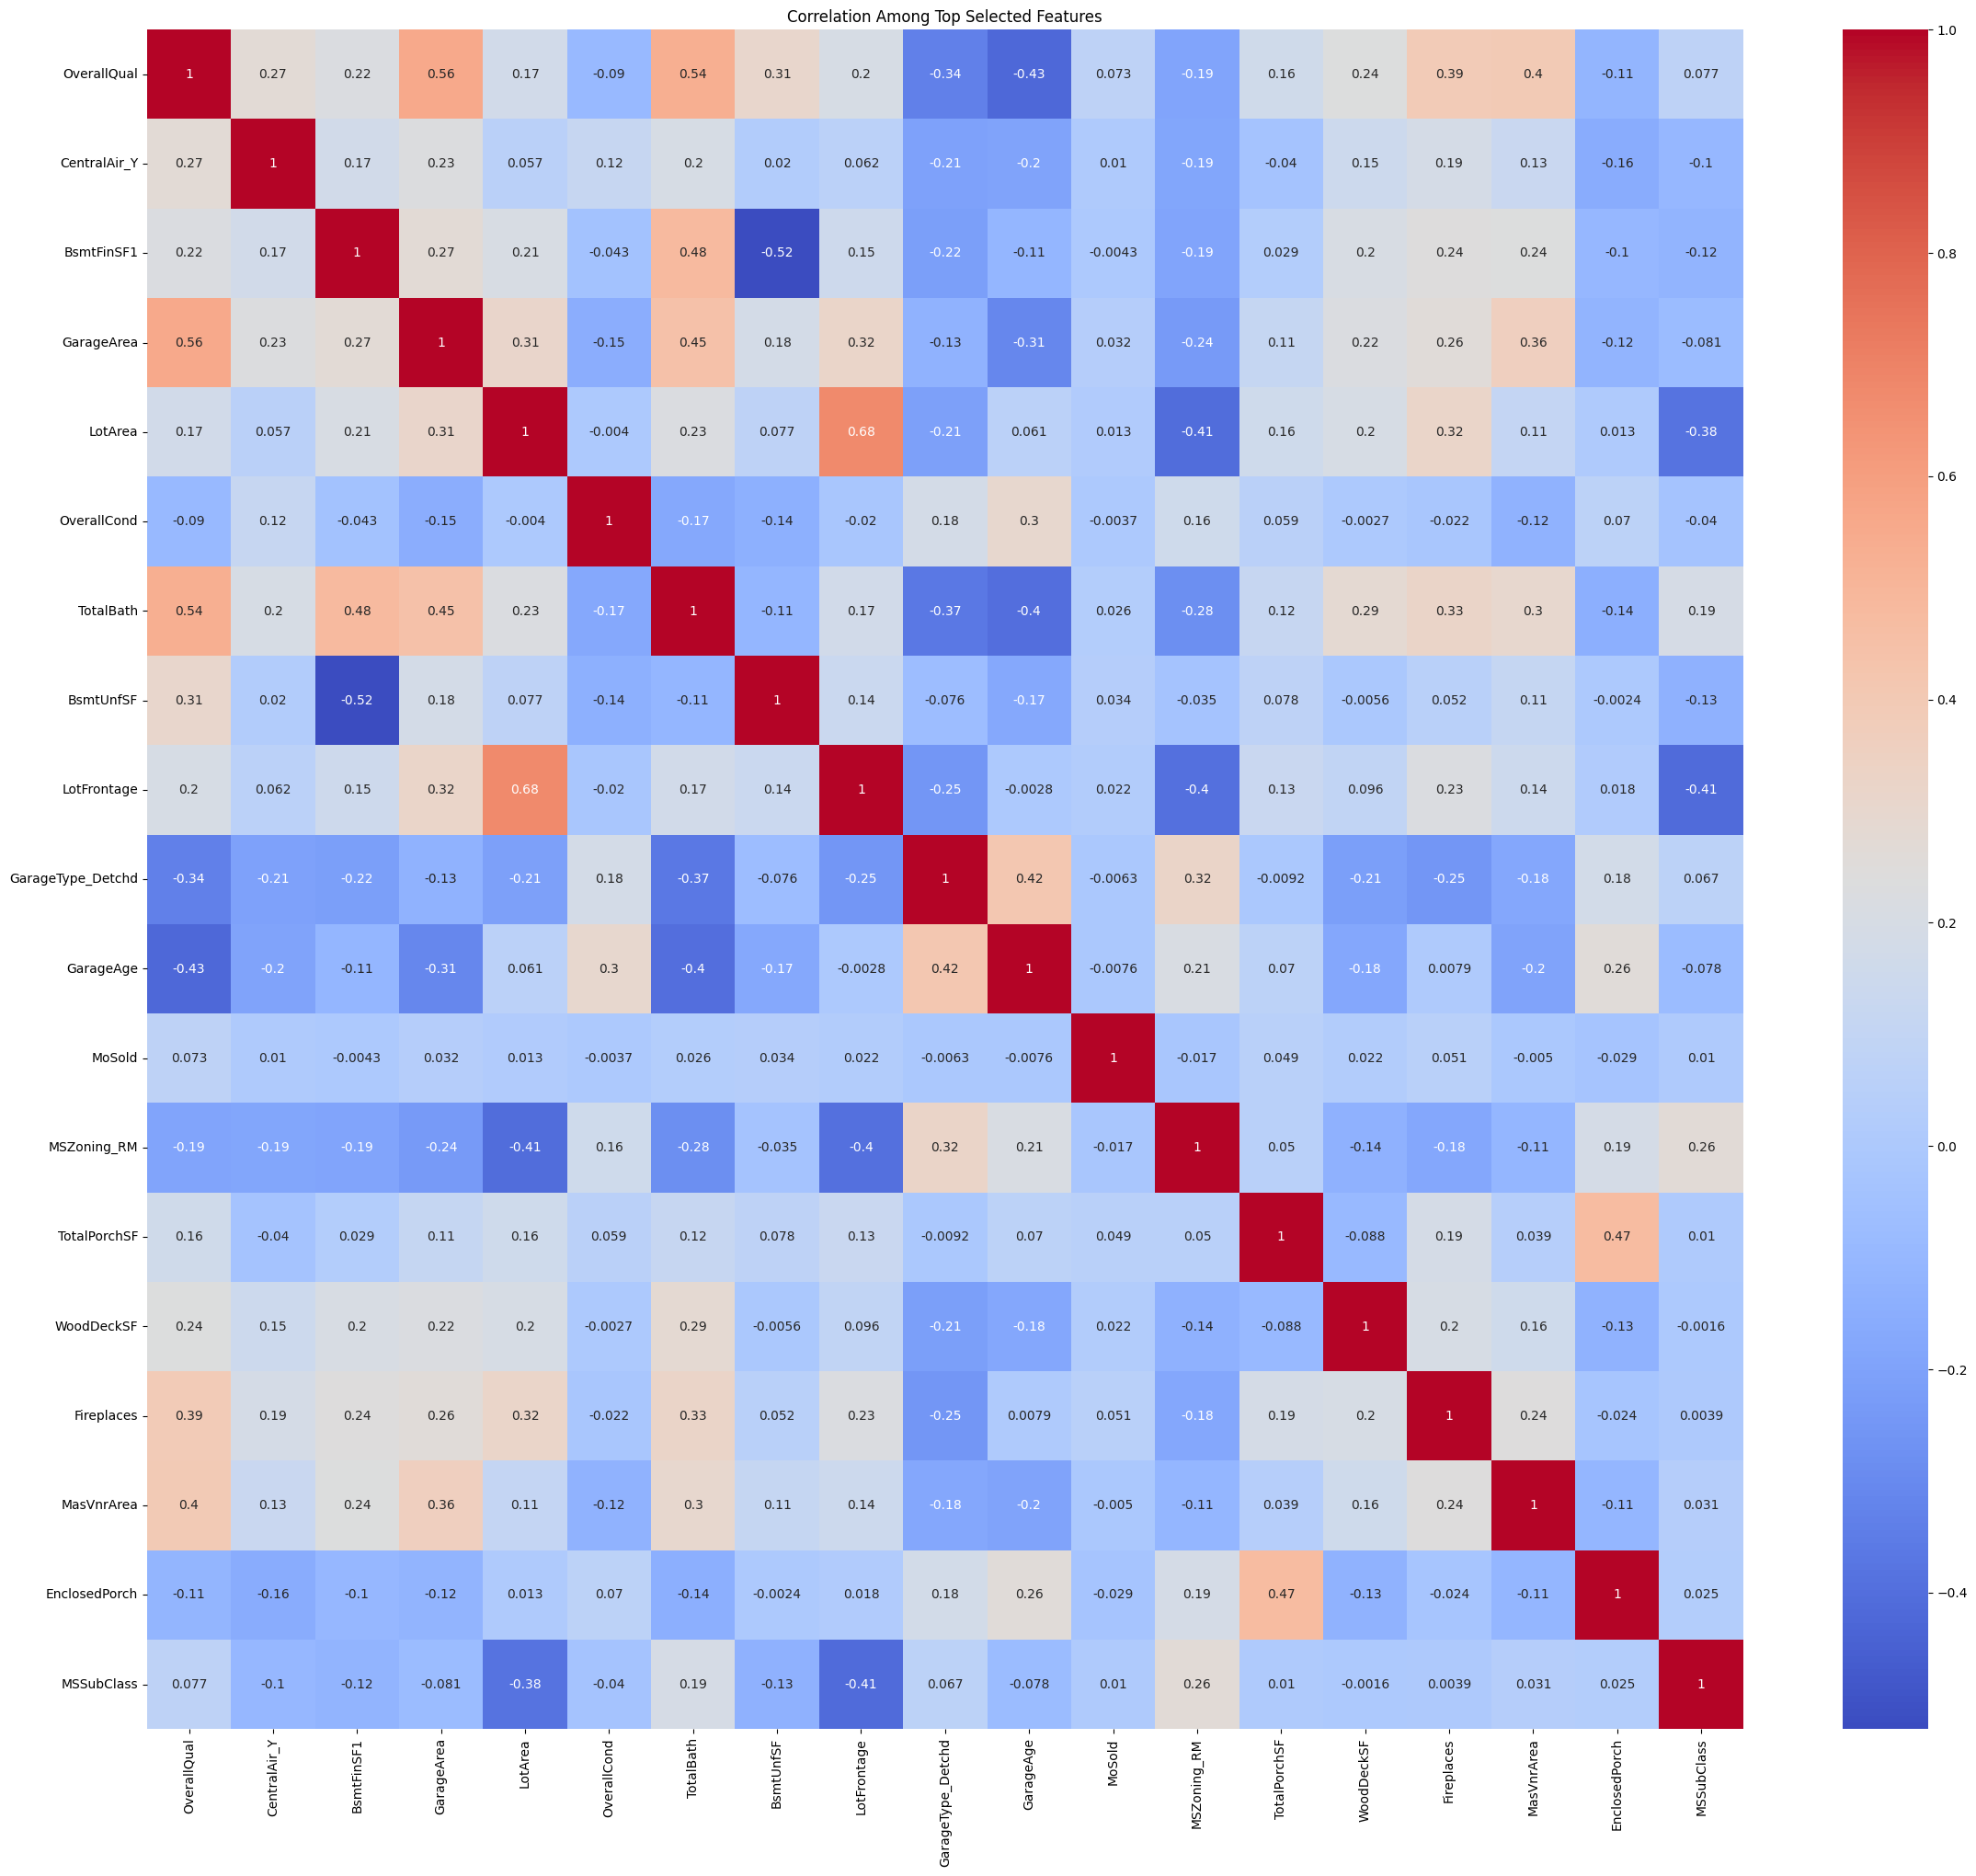

In [ ]:
top_corr_features = X[X_reduced.columns]
plt.figure(figsize=(28,24))
snsb.heatmap(top_corr_features.corr(), cmap='coolwarm', annot=True)
plt.title("Correlation Among Top Selected Features")
plt.show()

# Apply PCA (Principal Component Analysis)

In [ ]:
# # Scale the reduced features
# scaler = StandardScaler()
# X_scaled = scaler.fit_transform(X_reduced)

# #  Initialize PCA - keep 99% of explained variance
# pca = PCA(n_components=0.999, random_state=42)
# X_pca = pca.fit_transform(X_scaled)

# print(f"Original feature count: {X_reduced.shape[1]}")
# print(f"Reduced feature count after PCA: {X_pca.shape[1]}")
# print(f"Explained variance ratio sum: {pca.explained_variance_ratio_.sum():.2f}")

# #  Create DataFrame for clarity
# X_pca_df = pd.DataFrame(X_pca, columns=[f'PC{i+1}' for i in range(X_pca.shape[1])])


In [ ]:
# X_pca_df

# **USING FEATURES DIRECTLY WITHOUT PCA**

In [ ]:
X_final = X[X_reduced.columns].copy()

# **VARIOUS MODEL ANALYSIS**

In [ ]:
## Split the data

X_train, X_test, y_train, y_test = train_test_split(X_final, y, test_size=0.2, random_state=42)

# **1) MULTI-LINEAR REGRESSION**

In [ ]:
model = LinearRegression()

In [ ]:
# Train the model
model.fit(X_train, y_train)

# Cross-validation (to check generalization)
cv_scores = cross_val_score(model, X_train, y_train,
                            scoring='neg_root_mean_squared_error', cv=10)
print(" Cross-Validation RMSE:", -cv_scores.mean())

# Predictions on train & test sets
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

# Convert log values back to actual SalePrice
train_preds_real = np.expm1(y_train_pred)
test_preds_real = np.expm1(y_test_pred)
y_train_real = np.expm1(y_train)
y_test_real = np.expm1(y_test)

# Evaluate performance
train_rmse = np.sqrt(mean_squared_error(y_train_real, train_preds_real))
test_rmse = np.sqrt(mean_squared_error(y_test_real, test_preds_real))
train_r2 = r2_score(y_train_real, train_preds_real)
test_r2 = r2_score(y_test_real, test_preds_real)
overfitting = ((train_r2 - test_r2) / train_r2) * 100

print("\n Model Performance Summary:")
print("------------------------------")
print(f"Train RMSE: {train_rmse:,.2f}")
print(f"Test RMSE:  {test_rmse:,.2f}")
print(f"Train R²:   {train_r2:.3f}")
print(f"Test R²:    {test_r2:.3f}")
print("Model: Multi Linear Regression")
print(f"Overfitting %: {overfitting:.2f}%")

# Compare Actual vs Predicted Prices
comparison_df = pd.DataFrame({
    'Actual_Price': y_test_real,
    'Predicted_Price': test_preds_real
})

print("\n Sample Predictions:")
display(comparison_df.head(10))

 Cross-Validation RMSE: 0.14683023384744623

 Model Performance Summary:
------------------------------
Train RMSE: 28,672.09
Test RMSE:  26,280.25
Train R²:   0.874
Test R²:    0.875
Model: Multi Linear Regression
Overfitting %: -0.14%

 Sample Predictions:


,Actual_Price,Predicted_Price
1322,190000.0,224227.304923
837,100000.0,112767.740217
413,115000.0,114061.264141
522,159000.0,154470.186751
1036,315500.0,335355.254229
615,137500.0,165340.075045
218,311500.0,221993.831866
1032,310000.0,322662.496630
1289,281000.0,271029.349188
887,135500.0,139759.564185


## **VISUALS**

## **ACTUAL VS. PREDICTED PRICES**

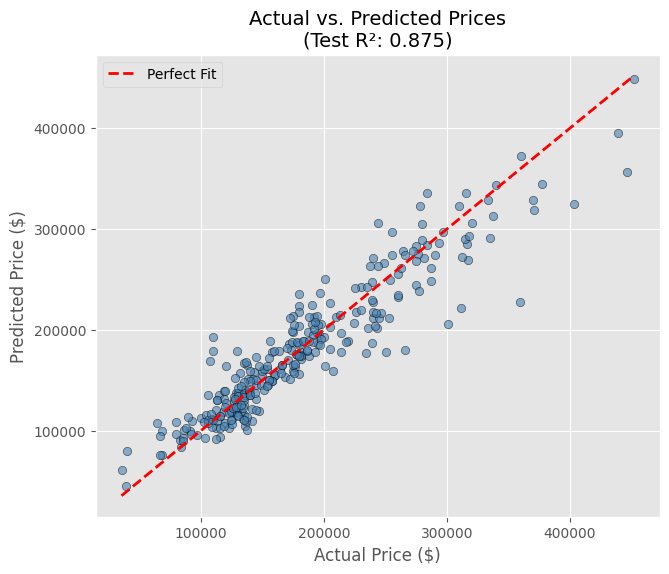

In [ ]:
plt.style.use('ggplot')
plt.figure(figsize=(16, 6))
plt.subplot(1, 2, 1)
snsb.scatterplot(x=y_test_real, y=test_preds_real, alpha=0.6, color='steelblue', edgecolor='k')

# Add a red diagonal line (The "Perfect Prediction" Line)
# If points fall on this line, the prediction is perfect.
max_val = max(max(y_test_real), max(test_preds_real))
min_val = min(min(y_test_real), min(test_preds_real))
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2, label='Perfect Fit')

plt.title(f'Actual vs. Predicted Prices\n(Test R²: {test_r2:.3f})', fontsize=14)
plt.xlabel('Actual Price ($)', fontsize=12)
plt.ylabel('Predicted Price ($)', fontsize=12)
plt.legend()
plt.grid(True)

## **RESIDUAL PLOT**

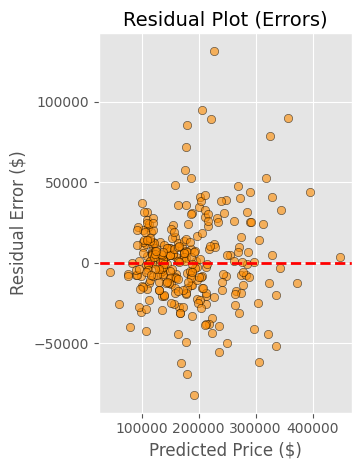

In [ ]:
# Residuals = Actual - Predicted
# We want these to be randomly scattered around the red 0 line.
plt.subplot(1, 2, 2)
residuals = y_test_real - test_preds_real
snsb.scatterplot(x=test_preds_real, y=residuals, alpha=0.6, color='darkorange', edgecolor='k')

# Add a horizontal line at 0
plt.axhline(y=0, color='red', linestyle='--', linewidth=2)

plt.title('Residual Plot (Errors)', fontsize=14)
plt.xlabel('Predicted Price ($)', fontsize=12)
plt.ylabel('Residual Error ($)', fontsize=12)
plt.grid(True)

plt.tight_layout()
plt.show()

## **DISTRIBUTION OF ERRORS**

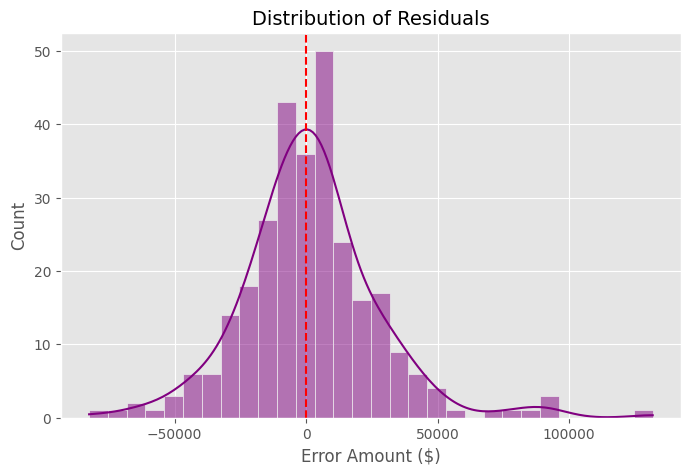

In [ ]:
# This checks if your errors are normally distributed (Bell curve)
plt.figure(figsize=(8, 5))
snsb.histplot(residuals, kde=True, color='purple', bins=30)
plt.title('Distribution of Residuals', fontsize=14)
plt.xlabel('Error Amount ($)', fontsize=12)
plt.axvline(x=0, color='red', linestyle='--')
plt.show()

# **2) RIDGE REGRESSION**

In [ ]:
# Hyperparameter grid
params = {
    'alpha': [0.001, 0.01, 0.1, 0.5, 1, 2, 5, 10, 15, 20]
}

ridge = GridSearchCV(
    estimator=Ridge(),
    param_grid=params,
    scoring='neg_root_mean_squared_error',
    cv=5,
    n_jobs=-1
)

# Train Ridge model
ridge.fit(X_train, y_train)

# Cross-validation
cv_scores = cross_val_score(ridge, X_train, y_train,
                            scoring='neg_root_mean_squared_error', cv=10)
print(" Cross-Validation RMSE:", -cv_scores.mean())

best_ridge = ridge.best_estimator_

print("Best Alpha:", ridge.best_params_)

# Predictions on train & test sets
y_train_pred = best_ridge.predict(X_train)
y_test_pred = best_ridge.predict(X_test)

# Convert log values back to actual SalePrice
train_preds_real = np.expm1(y_train_pred)
test_preds_real = np.expm1(y_test_pred)
y_train_real = np.expm1(y_train)
y_test_real = np.expm1(y_test)

# Evaluate performance
train_rmse = np.sqrt(mean_squared_error(y_train_real, train_preds_real))
test_rmse = np.sqrt(mean_squared_error(y_test_real, test_preds_real))
train_r2 = r2_score(y_train_real, train_preds_real)
test_r2 = r2_score(y_test_real, test_preds_real)
overfitting = ((train_r2 - test_r2) / train_r2) * 100

print("\n Model Performance Summary:")
print("------------------------------")
print(f"Train RMSE: {train_rmse:,.2f}")
print(f"Test RMSE:  {test_rmse:,.2f}")
print(f"Train R²:   {train_r2:.3f}")
print(f"Test R²:    {test_r2:.3f}")
print("Model: Ridge Regression")
print(f"Overfitting %: {overfitting:.2f}%")

# Compare Actual vs Predicted Prices
comparison_df = pd.DataFrame({
    'Actual_Price': y_test_real,
    'Predicted_Price': test_preds_real
})

print("\n Sample Predictions:")
display(comparison_df.head(10))

 Cross-Validation RMSE: 0.1468290019079164
Best Alpha: {'alpha': 2}

 Model Performance Summary:
------------------------------
Train RMSE: 28,673.37
Test RMSE:  26,278.54
Train R²:   0.874
Test R²:    0.875
Model: Ridge Regression
Overfitting %: -0.14%

 Sample Predictions:


,Actual_Price,Predicted_Price
1322,190000.0,224112.165864
837,100000.0,112763.797509
413,115000.0,114008.451277
522,159000.0,154497.344764
1036,315500.0,335531.456882
615,137500.0,165324.071937
218,311500.0,221892.269013
1032,310000.0,322652.063921
1289,281000.0,270996.252186
887,135500.0,139663.632022


## **VISUALS**

## **ACTUAL VS. PREDICTED PRICES**

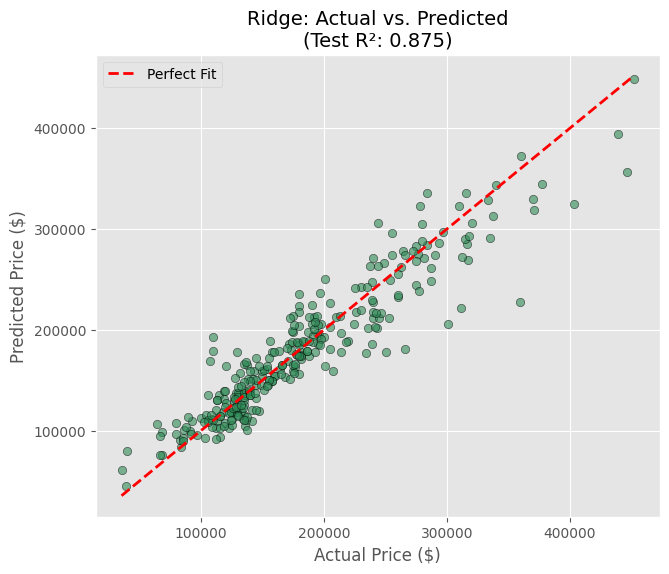

In [ ]:
# Set the plot style
plt.style.use('ggplot')

# Create a figure with 2 subplots (side by side)
plt.figure(figsize=(16, 6))

plt.subplot(1, 2, 1)
snsb.scatterplot(x=y_test_real, y=test_preds_real, alpha=0.6, color='seagreen', edgecolor='k')

# Add the "Perfect Prediction" Line
max_val = max(max(y_test_real), max(test_preds_real))
min_val = min(min(y_test_real), min(test_preds_real))
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2, label='Perfect Fit')

plt.title(f'Ridge: Actual vs. Predicted\n(Test R²: {test_r2:.3f})', fontsize=14)
plt.xlabel('Actual Price ($)', fontsize=12)
plt.ylabel('Predicted Price ($)', fontsize=12)
plt.legend()
plt.grid(True)

## **RESIDUAL PLOT**

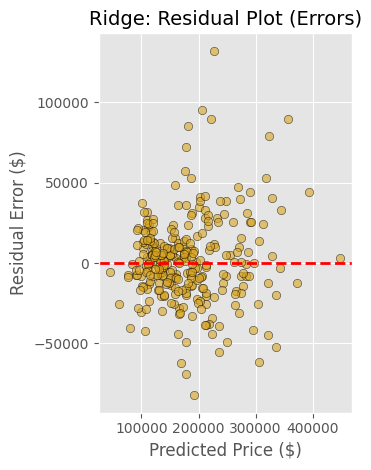

In [ ]:
plt.subplot(1, 2, 2)
residuals = y_test_real - test_preds_real
snsb.scatterplot(x=test_preds_real, y=residuals, alpha=0.6, color='goldenrod', edgecolor='k')

# Add a horizontal line at 0
plt.axhline(y=0, color='red', linestyle='--', linewidth=2)

plt.title('Ridge: Residual Plot (Errors)', fontsize=14)
plt.xlabel('Predicted Price ($)', fontsize=12)
plt.ylabel('Residual Error ($)', fontsize=12)
plt.grid(True)

plt.tight_layout()
plt.show()

## **DISTRIBUTION OF ERRORS**

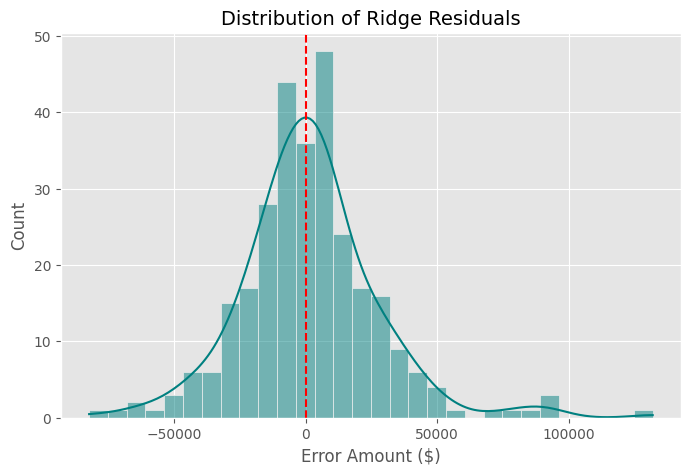

In [ ]:
plt.figure(figsize=(8, 5))
snsb.histplot(residuals, kde=True, color='teal', bins=30)
plt.title('Distribution of Ridge Residuals', fontsize=14)
plt.xlabel('Error Amount ($)', fontsize=12)
plt.axvline(x=0, color='red', linestyle='--')
plt.show()

# **3) LASSO REGRESSION**

In [ ]:
# Lasso with grid search
params = {
    'alpha': [0.0001, 0.0005, 0.001, 0.005, 0.01, 0.05, 0.1, 0.5, 1]
}

lasso = GridSearchCV(
    estimator=Lasso(max_iter=10000),
    param_grid=params,
    scoring='neg_root_mean_squared_error',
    cv=5,
    n_jobs=-1
)

# Cross-validation
cv_scores = cross_val_score(lasso, X_train, y_train,
                            scoring='neg_root_mean_squared_error', cv=10)
print(" Cross-Validation RMSE:", -cv_scores.mean())

lasso.fit(X_train, y_train)

best_lasso = lasso.best_estimator_

print("Best Alpha:", lasso.best_params_)

# Predictions on train & test sets
y_train_pred = best_lasso.predict(X_train)
y_test_pred = best_lasso.predict(X_test)

# Convert log values back to actual SalePrice
train_preds_real = np.expm1(y_train_pred)
test_preds_real = np.expm1(y_test_pred)
y_train_real = np.expm1(y_train)
y_test_real = np.expm1(y_test)

# Evaluate performance
train_rmse = np.sqrt(mean_squared_error(y_train_real, train_preds_real))
test_rmse = np.sqrt(mean_squared_error(y_test_real, test_preds_real))
train_r2 = r2_score(y_train_real, train_preds_real)
test_r2 = r2_score(y_test_real, test_preds_real)
overfitting = ((train_r2 - test_r2) / train_r2) * 100

print("\nLasso Performance:")
print(f"Train RMSE: ${train_rmse:,.2f}")
print(f"Test RMSE:  ${test_rmse:,.2f}")
print(f"Train R²:   {train_r2:.4f}")
print(f"Test R²:    {test_r2:.4f}")
print(f"Overfitting %: {overfitting:.2f}%")

# Compare Actual vs Predicted Prices
comparison_df = pd.DataFrame({
    'Actual_Price': y_test_real,
    'Predicted_Price': test_preds_real
})

print("\n Sample Predictions:")
display(comparison_df.head(10))

 Cross-Validation RMSE: 0.14669030044991122
Best Alpha: {'alpha': 0.0005}

Lasso Performance:
Train RMSE: $28,691.03
Test RMSE:  $26,319.47
Train R²:   0.8736
Test R²:    0.8746
Overfitting %: -0.11%

 Sample Predictions:


,Actual_Price,Predicted_Price
1322,190000.0,223332.284148
837,100000.0,113391.094605
413,115000.0,114282.735549
522,159000.0,154754.544854
1036,315500.0,336183.452644
615,137500.0,164622.792717
218,311500.0,221166.498884
1032,310000.0,321904.484809
1289,281000.0,270720.448534
887,135500.0,139508.699603


## **VISUALS**

## **ACTUAL VS. PREDICTED PRICES**

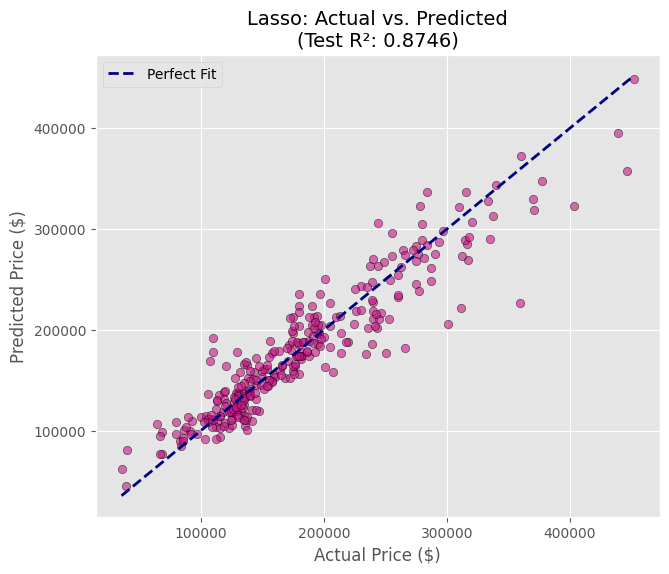

In [ ]:
# Set the plot style
plt.style.use('ggplot')

# Create a figure with 2 subplots (side by side)
plt.figure(figsize=(16, 6))

plt.subplot(1, 2, 1)
snsb.scatterplot(x=y_test_real, y=test_preds_real, alpha=0.6, color='mediumvioletred', edgecolor='k')

# Add the "Perfect Prediction" Line
max_val = max(max(y_test_real), max(test_preds_real))
min_val = min(min(y_test_real), min(test_preds_real))
plt.plot([min_val, max_val], [min_val, max_val], color='navy', linestyle='--', linewidth=2, label='Perfect Fit')

plt.title(f'Lasso: Actual vs. Predicted\n(Test R²: {test_r2:.4f})', fontsize=14)
plt.xlabel('Actual Price ($)', fontsize=12)
plt.ylabel('Predicted Price ($)', fontsize=12)
plt.legend()
plt.grid(True)

## **RESIDUAL PLOT**

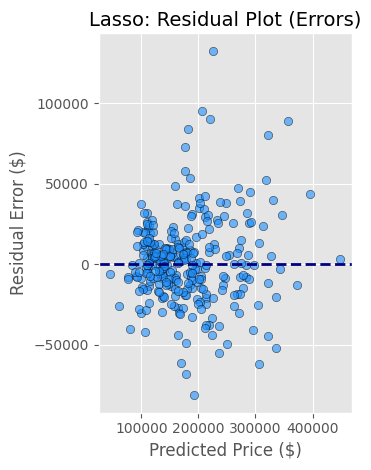

In [ ]:
plt.subplot(1, 2, 2)
residuals = y_test_real - test_preds_real
snsb.scatterplot(x=test_preds_real, y=residuals, alpha=0.6, color='dodgerblue', edgecolor='k')

# Add a horizontal line at 0
plt.axhline(y=0, color='navy', linestyle='--', linewidth=2)

plt.title('Lasso: Residual Plot (Errors)', fontsize=14)
plt.xlabel('Predicted Price ($)', fontsize=12)
plt.ylabel('Residual Error ($)', fontsize=12)
plt.grid(True)

plt.tight_layout()
plt.show()

## **DISTRIBUTION OF ERRORS**

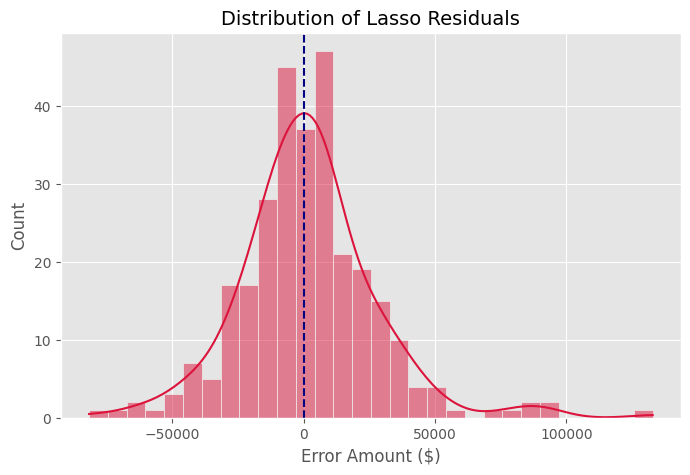

In [ ]:
plt.figure(figsize=(8, 5))
snsb.histplot(residuals, kde=True, color='crimson', bins=30)
plt.title('Distribution of Lasso Residuals', fontsize=14)
plt.xlabel('Error Amount ($)', fontsize=12)
plt.axvline(x=0, color='navy', linestyle='--')
plt.show()

# **4) XGBOOST REGRESSOR**

In [ ]:
# XGBoost with PROPER regularization
xgb = XGBRegressor(
    n_estimators=300,
    learning_rate=0.01,
    max_depth=3,
    min_child_weight=5,
    subsample=0.7,
    colsample_bytree=0.7,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1,
    early_stopping_rounds=50
)

xgb.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=False
)

# Predictions
y_train_pred = xgb.predict(X_train)
y_test_pred = xgb.predict(X_test)

# Convert back from log scale
train_preds_real = np.expm1(y_train_pred)
test_preds_real = np.expm1(y_test_pred)
y_train_real = np.expm1(y_train)
y_test_real = np.expm1(y_test)

# Evaluate
train_rmse = np.sqrt(mean_squared_error(y_train_real, train_preds_real))
test_rmse = np.sqrt(mean_squared_error(y_test_real, test_preds_real))
train_r2 = r2_score(y_train_real, train_preds_real)
test_r2 = r2_score(y_test_real, test_preds_real)
overfitting_pct = ((train_r2 - test_r2) / train_r2) * 100

print("\n XGBoost Performance (Regularized):")
print(f"Train RMSE: ${train_rmse:,.2f}")
print(f"Test RMSE:  ${test_rmse:,.2f}")
print(f"Train R²:   {train_r2:.4f}")
print(f"Test R²:    {test_r2:.4f}")
print(f"Overfitting: {overfitting_pct:.2f}%")

# Compare Actual vs Predicted Prices
comparison_df = pd.DataFrame({
    'Actual_Price': y_test_real,
    'Predicted_Price': test_preds_real
})

print("\n Sample Predictions:")
display(comparison_df.head(10))


 XGBoost Performance (Regularized):
Train RMSE: $31,491.66
Test RMSE:  $29,027.39
Train R²:   0.8477
Test R²:    0.8475
Overfitting: 0.03%

 Sample Predictions:


,Actual_Price,Predicted_Price
1322,190000.0,223298.859375
837,100000.0,129872.953125
413,115000.0,122863.304688
522,159000.0,144735.812500
1036,315500.0,322058.406250
615,137500.0,149833.968750
218,311500.0,201799.031250
1032,310000.0,308422.687500
1289,281000.0,279620.468750
887,135500.0,132764.546875


## **VISUALS**

## **ACTUAL VS. PREDICTED PRICES**

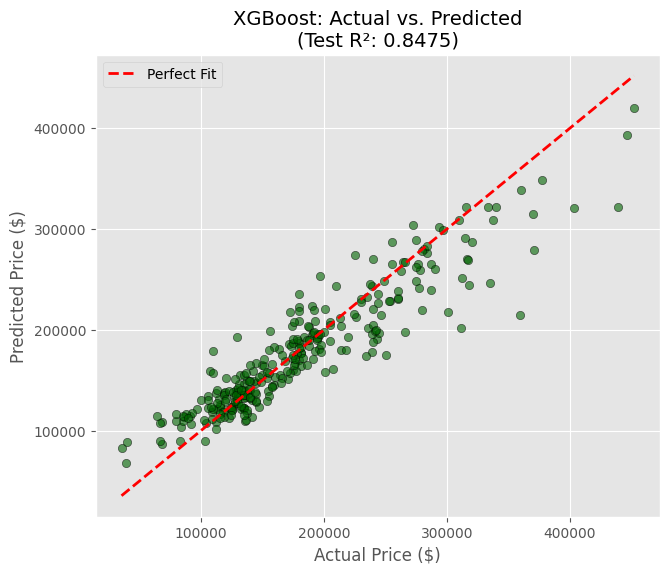

In [ ]:
# Set the plot style
plt.style.use('ggplot')

# Create a figure with 2 subplots (side by side)
plt.figure(figsize=(16, 6))

plt.subplot(1, 2, 1)
snsb.scatterplot(x=y_test_real, y=test_preds_real, alpha=0.6, color='darkgreen', edgecolor='k')

# Add the "Perfect Prediction" Line
max_val = max(max(y_test_real), max(test_preds_real))
min_val = min(min(y_test_real), min(test_preds_real))
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2, label='Perfect Fit')

plt.title(f'XGBoost: Actual vs. Predicted\n(Test R²: {test_r2:.4f})', fontsize=14)
plt.xlabel('Actual Price ($)', fontsize=12)
plt.ylabel('Predicted Price ($)', fontsize=12)
plt.legend()
plt.grid(True)

## **RESIDUAL PLOT**

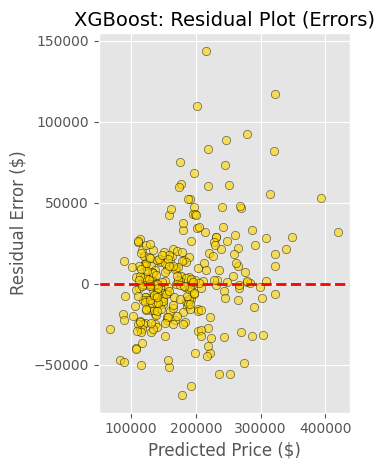

In [ ]:
plt.subplot(1, 2, 2)
residuals = y_test_real - test_preds_real
snsb.scatterplot(x=test_preds_real, y=residuals, alpha=0.6, color='gold', edgecolor='k')

# Add a horizontal line at 0
plt.axhline(y=0, color='red', linestyle='--', linewidth=2)

plt.title('XGBoost: Residual Plot (Errors)', fontsize=14)
plt.xlabel('Predicted Price ($)', fontsize=12)
plt.ylabel('Residual Error ($)', fontsize=12)
plt.grid(True)

plt.tight_layout()
plt.show()

## **DISTRIBUTION OF ERRORS**

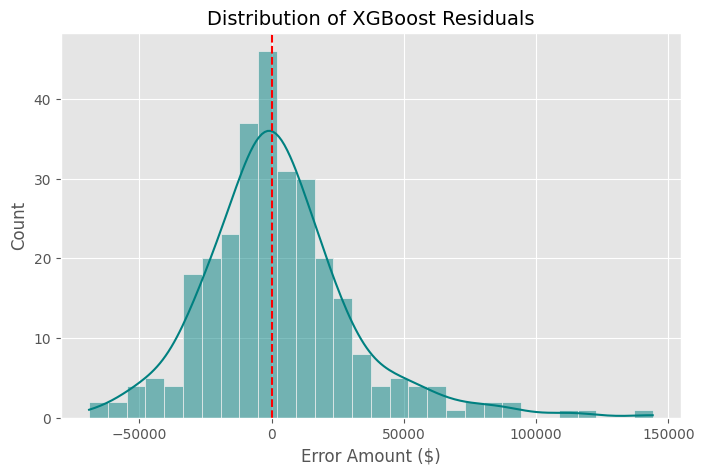

In [ ]:
plt.figure(figsize=(8, 5))
snsb.histplot(residuals, kde=True, color='teal', bins=30)
plt.title('Distribution of XGBoost Residuals', fontsize=14)
plt.xlabel('Error Amount ($)', fontsize=12)
plt.axvline(x=0, color='red', linestyle='--')
plt.show()

# **CONCLUSION**
This project aimed to predict house prices using a comprehensive dataset of housing features. The methodology involved several crucial steps: initial data extraction and cleaning, thorough handling of missing values (both numeric and categorical), extensive feature engineering to create more predictive variables, and a meticulous feature selection process. The feature selection combined Random Forest importance with multicollinearity checks using correlation heatmaps and Variance Inflation Factor (VIF) to ensure a robust and efficient set of predictors.

Four different regression models were then evaluated: Multi-Linear Regression, Ridge Regression, Lasso Regression, and XGBoost Regressor. Their performance was assessed using Root Mean Squared Error (RMSE) and R-squared (R²) on both training and test sets, along with an overfitting percentage to gauge generalization capability:

*   **Multi-Linear Regression:** Test RMSE: $26,280.25, Test R²: 0.875, Overfitting %: -0.14%

*   **Ridge Regression:** Test RMSE: $26,278.54, Test R²: 0.875, Overfitting %: -0.14%

*   **Lasso Regression:** Test RMSE: $26,319.47, Test R²: 0.8746, Overfitting %: -0.11%

*   **XGBoost Regressor:** Test RMSE: $29,027.39, Test R²: 0.8475, Overfitting %: 0.03%

Among the tested models, **Ridge Regression** demonstrated the best overall performance, achieving the lowest Test RMSE ($26,278.54) and a high Test R² of 0.875, indicating that approximately 87.5% of the variance in house prices can be explained by the selected features. Critically, its negative overfitting percentage suggests it generalized exceptionally well to unseen data, slightly outperforming Multi-Linear and Lasso Regression in this particular setup. While XGBoost is often powerful, in this specific configuration, the regularized linear models (Ridge and Lasso) showed a marginal edge in predictive accuracy and generalization, likely benefiting from the rigorous feature selection and scaling applied.
